In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


# 1- Logement des parisiens 

In [2]:
logement = pd.read_csv('logement.csv',sep=';',encoding='ISO-8859-1')


logement = logement.rename(columns = {'ID Bureau':'id_bv'})
logement = logement.set_index('id_bv',drop='True')


logement.head(5)

,habitat_principal,statut_logSocial,pour_logSocial,pourct_T1/T2,prix_immo_m2
id_bv,,,,,
01_01,ancien_standing,déficit,0.01,0.20,12.7
01_02,ancien_non_conforme,déficit,0.05,0.65,13.0
01_03,ancien_conforme,déficit,0.05,0.80,10.0
01_04,ancien_conforme,déficit,0.05,0.80,10.3
01_05,ancien_conforme,conforme,0.30,0.80,9.5


In [3]:
#On va compter les types d'habitation

compte_hab = logement["habitat_principal"].value_counts()

In [4]:
compte_hab

habitat_principal
ancien_conforme        272
privé récent           193
ancien_non_conforme    182
logement_social        151
ancien_standing         97
individuel               7
Name: count, dtype: int64

In [5]:
compte_hab = [272,182,97,193,150,8]
nom_hab = ['ancien_conforme','ancien_non_conforme','ancien_standing','privé récent','logement_social','individuel']

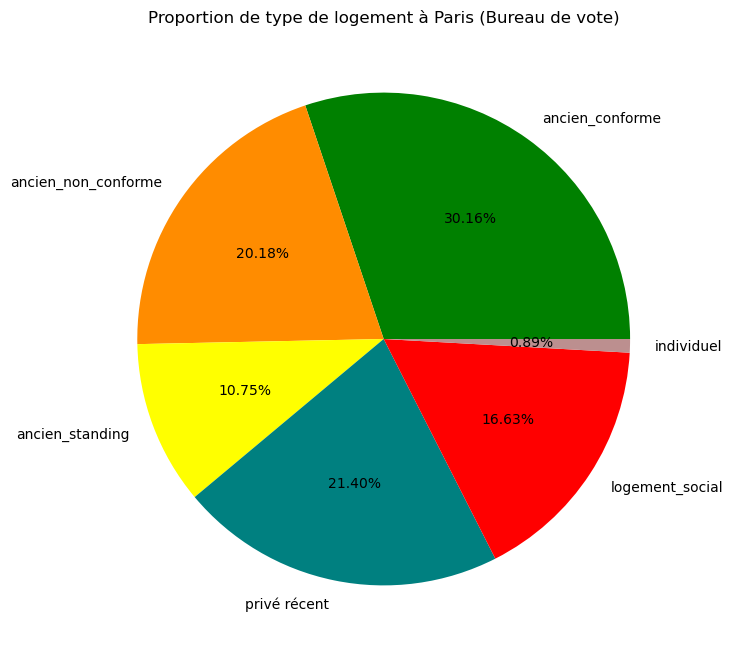

In [6]:
plt.figure(figsize=(10,8))

plt.pie(compte_hab,labels = nom_hab, colors = ['green','darkorange','yellow','teal','red','rosybrown'], autopct = '%.2f%%')

plt.title('Proportion de type de logement à Paris (Bureau de vote)')
plt.savefig("type_log_bv.png")

plt.show()

### 1-1 Analyse des résultats électorales par bureau de vote 

On va analyser les résultas des deux éléctions par bureau de vote en fonction de leur type d'habitation

In [7]:
#Fusionner les données avec les résultats des européennes

eur24 = pd.read_csv("res_europeennes_24.csv",sep=";",encoding="ISO-8859-1")

eur24 = eur24.rename(columns = {"ï»¿id_bv":"id_bv"})

#indexation de la 1er colonne
eur24 = eur24.set_index('id_bv',drop='True')

logement_eur = logement.merge(eur24,on='id_bv')



In [8]:
eur24

,nb_procu,nb_inscr,nb_abscent,taux_ab,nb_emarg,nb_votant,nb_blanc_null,nb_exprim,NB_ExtGauche,NB_Gauche,NB_Centre,NB_Droite,NB_ExtDroite,NB_Divers,eur_pol_dominant
id_bv,,,,,,,,,,,,,,,
01_01,37,1099,456,0.4149,643,643,4,639,0,157,144,72,114,14,Gauche
01_02,59,1232,537,0.4359,695,695,9,686,1,157,193,54,100,10,Centre
01_03,56,1225,468,0.3820,756,757,9,748,1,188,177,58,125,19,Gauche
01_04,48,1310,569,0.4344,741,741,9,732,3,211,146,51,124,21,Gauche
01_05,48,1090,444,0.4073,647,646,2,644,1,164,149,44,108,5,Gauche
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20_72,66,1763,785,0.4453,978,978,12,966,6,539,75,32,101,13,Gauche
20_73,0,1747,657,0.3761,1090,1090,4,1086,7,541,102,30,88,7,Gauche
20_74,110,1775,634,0.3572,1141,1141,9,1132,1,596,94,31,75,16,Gauche


In [9]:
logement_eur.head(5)

,habitat_principal,statut_logSocial,pour_logSocial,pourct_T1/T2,prix_immo_m2,nb_procu,nb_inscr,nb_abscent,taux_ab,nb_emarg,nb_votant,nb_blanc_null,nb_exprim,NB_ExtGauche,NB_Gauche,NB_Centre,NB_Droite,NB_ExtDroite,NB_Divers,eur_pol_dominant
id_bv,,,,,,,,,,,,,,,,,,,,
01_01,ancien_standing,déficit,0.01,0.20,12.7,37,1099,456,0.4149,643,643,4,639,0,157,144,72,114,14,Gauche
01_02,ancien_non_conforme,déficit,0.05,0.65,13.0,59,1232,537,0.4359,695,695,9,686,1,157,193,54,100,10,Centre
01_03,ancien_conforme,déficit,0.05,0.80,10.0,56,1225,468,0.3820,756,757,9,748,1,188,177,58,125,19,Gauche
01_04,ancien_conforme,déficit,0.05,0.80,10.3,48,1310,569,0.4344,741,741,9,732,3,211,146,51,124,21,Gauche
01_05,ancien_conforme,conforme,0.30,0.80,9.5,48,1090,444,0.4073,647,646,2,644,1,164,149,44,108,5,Gauche


In [10]:
leg24 = pd.read_csv("res_legislatives_24.csv",sep=";",encoding="ISO-8859-1")

leg24 = leg24.rename(columns = {"ï»¿id_bv":"id_bv"})


#indexation de la 1er colonne
leg24 = leg24.set_index('id_bv',drop='True')

logement_leg = logement.merge(leg24,on='id_bv')

logement_leg.head(5)

,habitat_principal,statut_logSocial,pour_logSocial,pourct_T1/T2,prix_immo_m2,num_circo,nb_procu,nb_inscr,nb_emarg,nb_votant,nb_bl,nb_nul,nb_exprim,NB_ExtGauche,NB_Gauche,NB_Centre,NB_Droite,NB_ExtDroite,NB_Divers
id_bv,,,,,,,,,,,,,,,,,,,
01_01,ancien_standing,déficit,0.01,0.20,12.7,1,129,1080,781,781,7,1,773,3,279,324,70,96,1
01_02,ancien_non_conforme,déficit,0.05,0.65,13.0,1,137,1211,904,904,5,4,895,0,312,414,73,91,5
01_03,ancien_conforme,déficit,0.05,0.80,10.0,1,140,1211,874,874,3,5,866,8,315,346,65,130,2
01_04,ancien_conforme,déficit,0.05,0.80,10.3,1,133,1295,912,912,7,5,900,18,416,315,45,106,0
01_05,ancien_conforme,conforme,0.30,0.80,9.5,1,145,1077,823,823,3,2,818,1,320,356,56,82,3


#### Ancien conforme 

On analyse les résultats des deux élections pour les habitants des anciens conformes

In [11]:
ancien_conforme_eur = logement_eur[logement_eur["habitat_principal"] == "ancien_conforme"]

# Resultats des parties 

res_ancien_conforme_eur = [np.sum(ancien_conforme_eur['NB_ExtGauche']),
                    np.sum(ancien_conforme_eur['NB_Gauche']),
                    np.sum(ancien_conforme_eur['NB_Centre']),
                    np.sum(ancien_conforme_eur['NB_Droite']),
                    np.sum(ancien_conforme_eur['NB_ExtDroite']),
                    np.sum(ancien_conforme_eur['NB_Divers'])]


ancien_conforme_leg = logement_leg[logement_leg["habitat_principal"] == "ancien_conforme"]

# Resultats des parties 

res_ancien_conforme_leg = [np.sum(ancien_conforme_leg['NB_ExtGauche']),
                    np.sum(ancien_conforme_leg['NB_Gauche']),
                    np.sum(ancien_conforme_leg['NB_Centre']),
                    np.sum(ancien_conforme_leg['NB_Droite']),
                    np.sum(ancien_conforme_leg['NB_ExtDroite']),
                    np.sum(ancien_conforme_leg['NB_Divers'])]





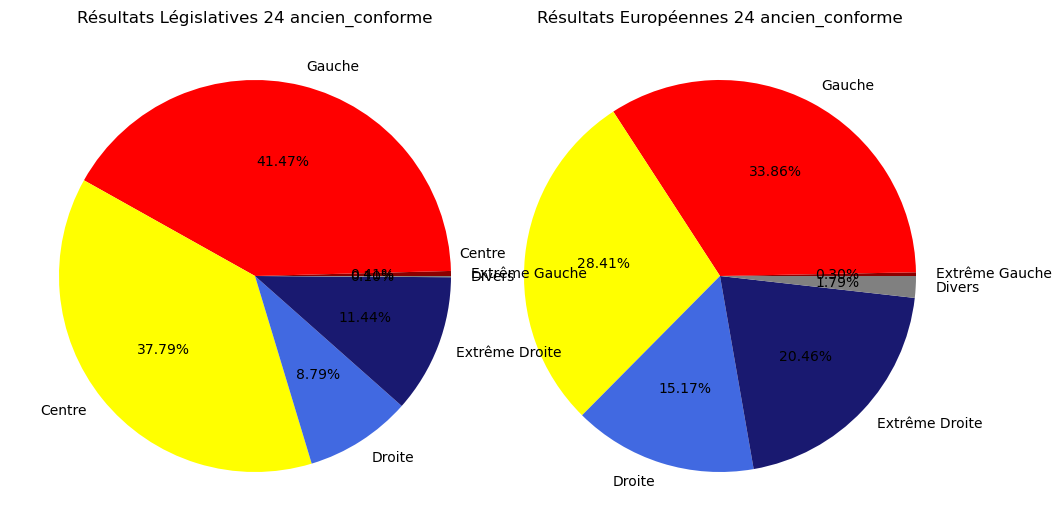

In [12]:
#Diagramme circulaire
plt.figure(figsize=(22,14))


plt.subplot(2,1,1)
plt.pie(res_ancien_conforme_eur,labels = ["Extrême Gauche","Gauche","Centre","Droite","Extrême Droite","Divers"],
        colors = ['darkred','red','yellow','royalblue','midnightblue','grey'],autopct = '%.2f%%')
plt.title("Résultats Européennes 24 ancien_conforme")


plt.subplot(2,2,1)
plt.pie(res_ancien_conforme_leg,labels = ["Extrême Gauche","Gauche","Centre","Droite","Extrême Droite","Divers"],
        colors = ['darkred','red','yellow','royalblue','midnightblue','grey'],autopct = '%.2f%%')
plt.title("Résultats Législatives 24 ancien_conforme")



plt.savefig("res24_ancien_conforme.png")

plt.show()

### Ancien non-conforme

On analyse les résultats des élections pour les habitant des anciens non-conforme

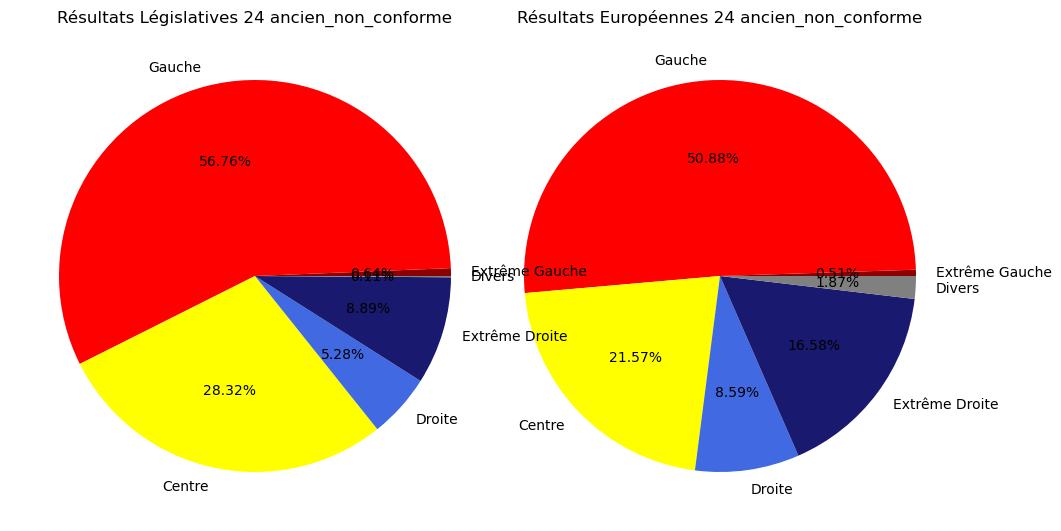

In [13]:
# Européennes

ancien_non_conforme_eur = logement_eur[logement_eur["habitat_principal"] == "ancien_non_conforme"]


res_ancien_non_conforme_eur = [np.sum(ancien_non_conforme_eur['NB_ExtGauche']),
                    np.sum(ancien_non_conforme_eur['NB_Gauche']),
                    np.sum(ancien_non_conforme_eur['NB_Centre']),
                    np.sum(ancien_non_conforme_eur['NB_Droite']),
                    np.sum(ancien_non_conforme_eur['NB_ExtDroite']),
                    np.sum(ancien_non_conforme_eur['NB_Divers'])]


#Legislative

ancien_non_conforme_leg = logement_leg[logement_leg["habitat_principal"] == "ancien_non_conforme"]


res_ancien_non_conforme_leg = [np.sum(ancien_non_conforme_leg['NB_ExtGauche']),
                    np.sum(ancien_non_conforme_leg['NB_Gauche']),
                    np.sum(ancien_non_conforme_leg['NB_Centre']),
                    np.sum(ancien_non_conforme_leg['NB_Droite']),
                    np.sum(ancien_non_conforme_leg['NB_ExtDroite']),
                    np.sum(ancien_non_conforme_leg['NB_Divers'])]


#Diagramme circulaire
plt.figure(figsize=(22,14))


plt.subplot(2,1,1)
plt.pie(res_ancien_non_conforme_eur,labels = ["Extrême Gauche","Gauche","Centre","Droite","Extrême Droite","Divers"],
        colors = ['darkred','red','yellow','royalblue','midnightblue','grey'],autopct = '%.2f%%')
plt.title("Résultats Européennes 24 ancien_non_conforme")


plt.subplot(2,2,1)
plt.pie(res_ancien_non_conforme_leg,labels = ["Extrême Gauche","Gauche","Centre","Droite","Extrême Droite","Divers"],
        colors = ['darkred','red','yellow','royalblue','midnightblue','grey'],autopct = '%.2f%%')
plt.title("Résultats Législatives 24 ancien_non_conforme")


plt.savefig("res24_ancien_non_conforme.png")

plt.show()


### Ancien standing 

On va anlyser les résultats des élections pour les habitants des anciens standing : les batiments anciens et luxieux 

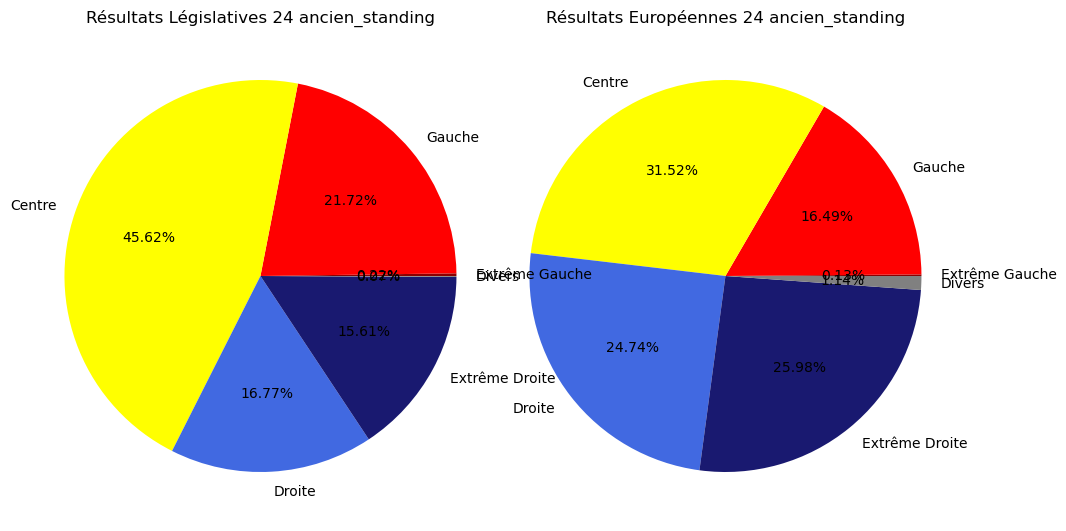

In [14]:


# Européennes

ancien_standing_eur = logement_eur[logement_eur["habitat_principal"] == "ancien_standing"]


res_ancien_standing_eur = [np.sum(ancien_standing_eur['NB_ExtGauche']),
                    np.sum(ancien_standing_eur['NB_Gauche']),
                    np.sum(ancien_standing_eur['NB_Centre']),
                    np.sum(ancien_standing_eur['NB_Droite']),
                    np.sum(ancien_standing_eur['NB_ExtDroite']),
                    np.sum(ancien_standing_eur['NB_Divers'])]


#Legislative

ancien_standing_leg = logement_leg[logement_leg["habitat_principal"] == "ancien_standing"]


res_ancien_standing_leg = [np.sum(ancien_standing_leg['NB_ExtGauche']),
                    np.sum(ancien_standing_leg['NB_Gauche']),
                    np.sum(ancien_standing_leg['NB_Centre']),
                    np.sum(ancien_standing_leg['NB_Droite']),
                    np.sum(ancien_standing_leg['NB_ExtDroite']),
                    np.sum(ancien_standing_leg['NB_Divers'])]


#Diagramme circulaire
plt.figure(figsize=(22,14))


plt.subplot(2,1,1)
plt.pie(res_ancien_standing_eur,labels = ["Extrême Gauche","Gauche","Centre","Droite","Extrême Droite","Divers"],
        colors = ['darkred','red','yellow','royalblue','midnightblue','grey'],autopct = '%.2f%%')
plt.title("Résultats Européennes 24 ancien_standing")


plt.subplot(2,2,1)
plt.pie(res_ancien_standing_leg,labels = ["Extrême Gauche","Gauche","Centre","Droite","Extrême Droite","Divers"],
        colors = ['darkred','red','yellow','royalblue','midnightblue','grey'],autopct = '%.2f%%')
plt.title("Résultats Législatives 24 ancien_standing")



plt.savefig("res24_ancien_standing.png")

plt.show()

### Résidence privé récent 

On va analyser les résultats des deux élections pour les habitants des privés récents 

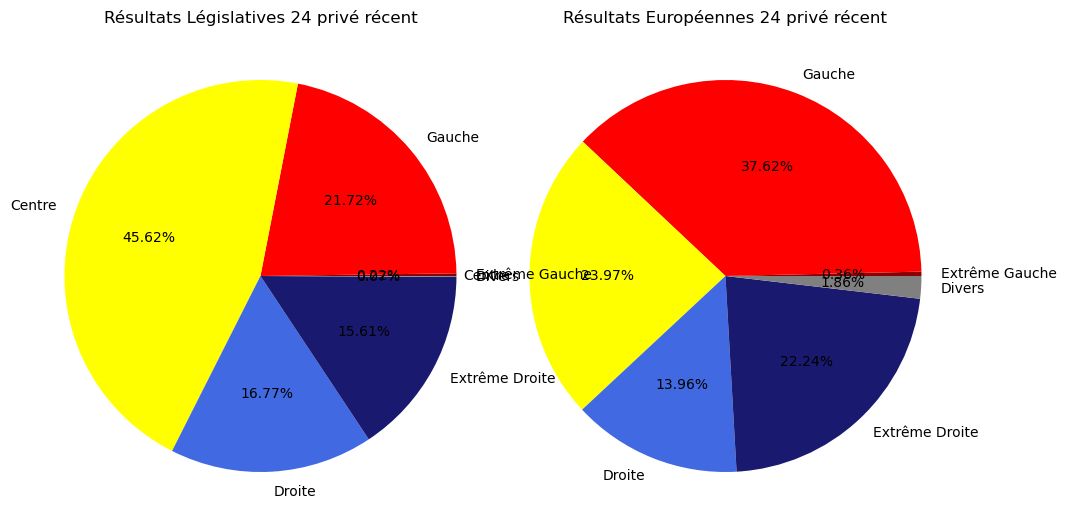

In [15]:

# Européennes

prive_eur = logement_eur[logement_eur["habitat_principal"] == "privé récent"]


res_prive_eur = [np.sum(prive_eur['NB_ExtGauche']),
                    np.sum(prive_eur['NB_Gauche']),
                    np.sum(prive_eur['NB_Centre']),
                    np.sum(prive_eur['NB_Droite']),
                    np.sum(prive_eur['NB_ExtDroite']),
                    np.sum(prive_eur['NB_Divers'])]


#Legislative

prive_leg = logement_leg[logement_leg["habitat_principal"] == "ancien_standing"]


res_prive_leg = [np.sum(prive_leg['NB_ExtGauche']),
                    np.sum(prive_leg['NB_Gauche']),
                    np.sum(prive_leg['NB_Centre']),
                    np.sum(prive_leg['NB_Droite']),
                    np.sum(prive_leg['NB_ExtDroite']),
                    np.sum(prive_leg['NB_Divers'])]


#Diagramme circulaire
plt.figure(figsize=(22,14))


plt.subplot(2,1,1)
plt.pie(res_prive_eur,labels = ["Extrême Gauche","Gauche","Centre","Droite","Extrême Droite","Divers"],
        colors = ['darkred','red','yellow','royalblue','midnightblue','grey'],autopct = '%.2f%%')
plt.title("Résultats Européennes 24 privé récent")
plt.savefig("eur24_res_prive.png")


plt.subplot(2,2,1)
plt.pie(res_prive_leg,labels = ["Extrême Gauche","Gauche","Centre","Droite","Extrême Droite","Divers"],
        colors = ['darkred','red','yellow','royalblue','midnightblue','grey'],autopct = '%.2f%%')
plt.title("Résultats Législatives 24 privé récent")


plt.savefig("res24_prive.png")

plt.show()

### Logement sociale 

On analyse des deux élections pour les habitants des logements sociales 

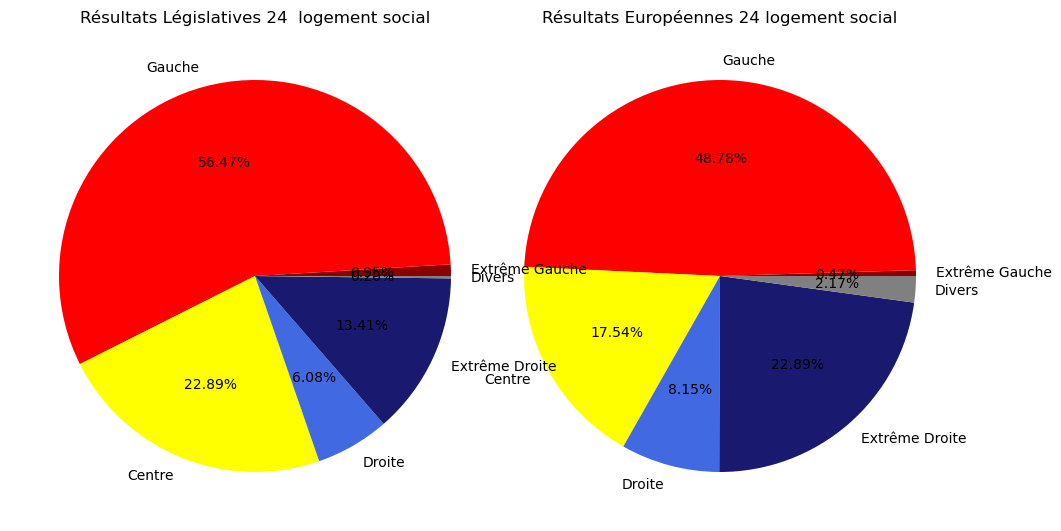

In [16]:
# Européennes

social_eur = logement_eur[logement_eur["habitat_principal"] == "logement_social"]


res_social_eur = [np.sum(social_eur['NB_ExtGauche']),
                    np.sum(social_eur['NB_Gauche']),
                    np.sum(social_eur['NB_Centre']),
                    np.sum(social_eur['NB_Droite']),
                    np.sum(social_eur['NB_ExtDroite']),
                    np.sum(social_eur['NB_Divers'])]


#Legislative

social_leg = logement_leg[logement_leg["habitat_principal"] == "logement_social"]


res_social_leg = [np.sum(social_leg['NB_ExtGauche']),
                    np.sum(social_leg['NB_Gauche']),
                    np.sum(social_leg['NB_Centre']),
                    np.sum(social_leg['NB_Droite']),
                    np.sum(social_leg['NB_ExtDroite']),
                    np.sum(social_leg['NB_Divers'])]


#Diagramme circulaire
plt.figure(figsize=(22,14))


plt.subplot(2,1,1)
plt.pie(res_social_eur,labels = ["Extrême Gauche","Gauche","Centre","Droite","Extrême Droite","Divers"],
        colors = ['darkred','red','yellow','royalblue','midnightblue','grey'],autopct = '%.2f%%')
plt.title("Résultats Européennes 24 logement social")
plt.savefig("eur24_res_social.png")


#législative
plt.subplot(2,2,1)
plt.pie(res_social_leg,labels = ["Extrême Gauche","Gauche","Centre","Droite","Extrême Droite","Divers"],
        colors = ['darkred','red','yellow','royalblue','midnightblue','grey'],autopct = '%.2f%%')
plt.title("Résultats Législatives 24  logement social")

plt.savefig("res24_social.png")

plt.show()

### Individuel 

On analyse les résultats des deux élections pour les habitants des lieux individuel (zone pavillonnaire)

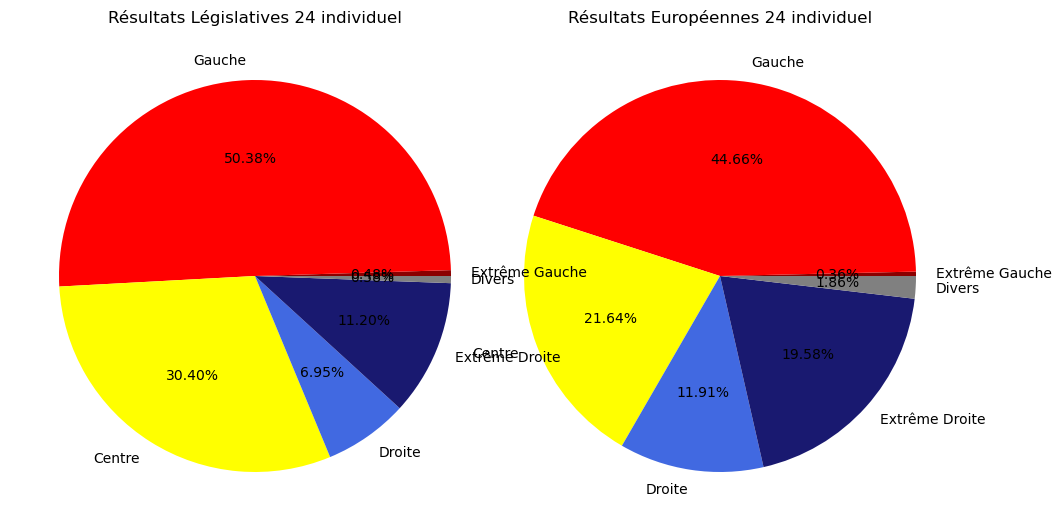

In [17]:
# Européennes

individuel_eur = logement_eur[logement_eur["habitat_principal"] == "individuel"]


res_individuel_eur = [np.sum(individuel_eur['NB_ExtGauche']),
                    np.sum(individuel_eur['NB_Gauche']),
                    np.sum(individuel_eur['NB_Centre']),
                    np.sum(individuel_eur['NB_Droite']),
                    np.sum(individuel_eur['NB_ExtDroite']),
                    np.sum(individuel_eur['NB_Divers'])]


#Legislative

individuel_leg = logement_leg[logement_leg["habitat_principal"] == "individuel"]


res_individuel_leg = [np.sum(individuel_leg['NB_ExtGauche']),
                    np.sum(individuel_leg['NB_Gauche']),
                    np.sum(individuel_leg['NB_Centre']),
                    np.sum(individuel_leg['NB_Droite']),
                    np.sum(individuel_leg['NB_ExtDroite']),
                    np.sum(individuel_leg['NB_Divers'])]


#Diagramme circulaire
plt.figure(figsize=(22,14))


plt.subplot(2,1,1)
plt.pie(res_individuel_eur,labels = ["Extrême Gauche","Gauche","Centre","Droite","Extrême Droite","Divers"],
        colors = ['darkred','red','yellow','royalblue','midnightblue','grey'],autopct = '%.2f%%')
plt.title("Résultats Européennes 24 individuel")


plt.subplot(2,2,1)
plt.pie(res_individuel_leg,labels = ["Extrême Gauche","Gauche","Centre","Droite","Extrême Droite","Divers"],
        colors = ['darkred','red','yellow','royalblue','midnightblue','grey'],autopct = '%.2f%%')
plt.title("Résultats Législatives 24 individuel")


plt.savefig("res24_individuel.png")

plt.show()

### 1-2  Electorat de gauche 

On va analyser les différents résultats des différentes parties de la gauche française. Pour cela on utlisera seulement les résultats des derniers européennes de juin 2024 pour avoir une idée 

In [18]:
# Resultats des européennes

gauche =  pd.read_csv('res_gauche.csv',sep=';',encoding='ISO-8859-1')

gauche = gauche.rename(columns = {'ï»¿id_bv':'id_bv'})

gauche = gauche.set_index('id_bv',drop='True')

#Fusion de données avec les données des logements
gauche_logement = logement.merge(gauche,on='id_bv')

gauche_logement.head(10)

,habitat_principal,statut_logSocial,pour_logSocial,pourct_T1/T2,prix_immo_m2,total_G_EUR,total_G_LEG,ecart_voix_G,p_G_EUR,p_G_LEG,nb_PS,nb_EELV,nb_PCF,nb_LFI,autresGauche,ExtGauche,partie_dominant
id_bv,,,,,,,,,,,,,,,,,
01_01,ancien_standing,déficit,0.01,0.20,12.7,295,282,-13,"0,4617","0,3648",136,66,4,84,3,2,Partie Socialiste
01_02,ancien_non_conforme,déficit,0.05,0.65,13.0,329,312,-17,"0,4796","0,3486",171,72,5,71,9,1,Partie Socialiste
01_03,ancien_conforme,déficit,0.05,0.80,10.0,369,323,-46,"0,4933","0,3730",178,86,11,86,5,3,Partie Socialiste
01_04,ancien_conforme,déficit,0.05,0.80,10.3,390,434,44,"0,5328","0,4822",175,66,15,125,5,4,Partie Socialiste
01_05,ancien_conforme,conforme,0.30,0.80,9.5,338,321,-17,"0,5248","0,3924",173,79,5,75,5,1,Partie Socialiste
01_06,ancien_non_conforme,déficit,0.05,0.65,11.0,379,339,-40,"0,4834","0,3742",189,88,8,87,3,4,Partie Socialiste
01_07,ancien_conforme,déficit,0.05,0.65,14.0,303,259,-44,"0,4202","0,3213",156,60,8,70,4,5,Partie Socialiste
01_08,ancien_conforme,déficit,0.05,0.65,13.0,181,173,-8,"0,3261","0,2574",96,47,3,34,1,0,Partie Socialiste
01_09,ancien_non_conforme,déficit,0.05,0.65,12.5,166,148,-18,"0,2862","0,2229",91,28,2,43,2,0,Partie Socialiste


On split les données pour les natures des habitations

In [19]:
#Ancien conforme
gauche_conforme = gauche_logement[gauche_logement['habitat_principal'] == 'ancien_conforme']

#Ancien non conforme
gauche_non_conforme = gauche_logement[gauche_logement['habitat_principal'] == 'ancien_non_conforme']

#Ancien standing
gauche_standing = gauche_logement[gauche_logement['habitat_principal'] == 'ancien_standing']

#Résidence privé récent
gauche_prive = gauche_logement[gauche_logement['habitat_principal'] == 'privé récent']

#Logement sociale 
gauche_social = gauche_logement[gauche_logement['habitat_principal'] == 'logement_social']

#individuel 
gauche_individuel = gauche_logement[gauche_logement['habitat_principal'] == 'individuel']




#### Report de voix de gauche

In [20]:
## ancien conforme 

conforme_voixG = np.sum(gauche_conforme['total_G_LEG']-gauche_conforme['total_G_EUR'])

#Ancien non conforme
non_conforme_voixG = np.sum(gauche_non_conforme['total_G_LEG']-gauche_non_conforme['total_G_EUR'])

#Ancien standing
standing_voixG = np.sum(gauche_standing['total_G_LEG']-gauche_standing['total_G_EUR'])

#Résidence privé récent
prive_voixG = np.sum(gauche_prive['total_G_LEG']-gauche_prive['total_G_EUR'])

#Logement sociale 
social_voixG = np.sum(gauche_social['total_G_LEG']-gauche_social['total_G_EUR'])

#individuel 
individuel_voixG = np.sum(gauche_individuel['total_G_LEG']-gauche_individuel['total_G_EUR'])


In [21]:
ecartG = [conforme_voixG,non_conforme_voixG,standing_voixG,prive_voixG,social_voixG,individuel_voixG]

In [22]:
ecartG

[-646, 9449, -3213, 6374, 15742, 115]

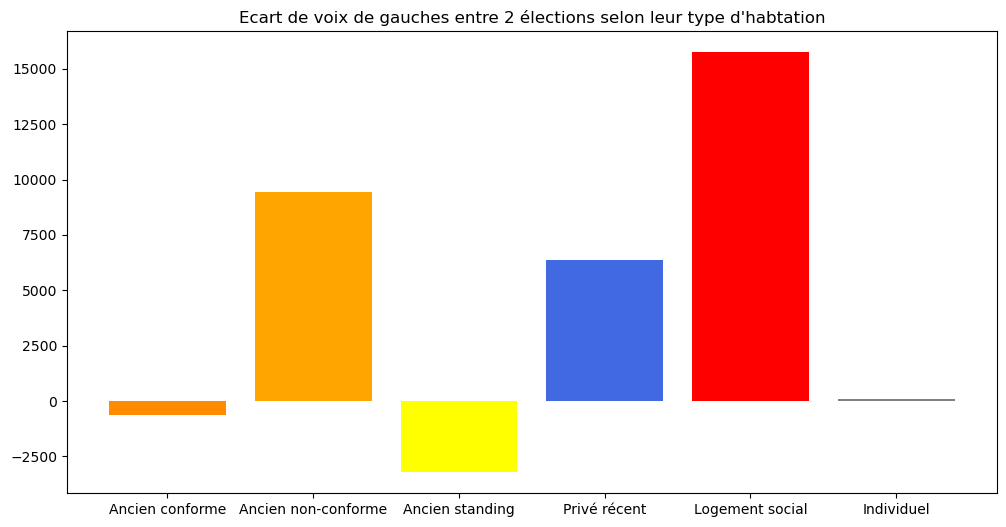

In [23]:
# Diagramme en barre 

plt.figure(figsize=(12,6))

names = ['Ancien conforme','Ancien non-conforme','Ancien standing','Privé récent','Logement social','Individuel']

plt.bar(names,ecartG,color = ['darkorange','orange','yellow','royalblue','red','grey']) 
plt.title("Ecart de voix de gauches entre 2 élections selon leur type d'habtation")


plt.savefig("ecart_G_log.png")

plt.show()

#### Nombre de voix par parties 

Nous allons voir les proportions des votes des parties de gauches selon leurs habitations

In [24]:
# Ancien conforme

conforme_G = [np.sum(gauche_conforme['ExtGauche']),
              np.sum(gauche_conforme['nb_LFI']),
              np.sum(gauche_conforme['nb_EELV']),
              np.sum(gauche_conforme['nb_PCF']),
              np.sum(gauche_conforme['nb_PS']),
              np.sum(gauche_conforme['autresGauche'])]


# Ancien non-conforme

non_conforme_G = [np.sum(gauche_non_conforme['ExtGauche']),
                  np.sum(gauche_non_conforme['nb_LFI']),
                  np.sum(gauche_non_conforme['nb_EELV']),
                  np.sum(gauche_non_conforme['nb_PCF']),
                  np.sum(gauche_non_conforme['nb_PS']),
                  np.sum(gauche_non_conforme['autresGauche'])]


# Ancien standing

standing_G = [np.sum(gauche_standing['ExtGauche']),
              np.sum(gauche_standing['nb_LFI']),
              np.sum(gauche_standing['nb_EELV']),
              np.sum(gauche_standing['nb_PCF']),
              np.sum(gauche_standing['nb_PS']),
              np.sum(gauche_standing['autresGauche'])]


# Privé récent

prive_G = [np.sum(gauche_prive['ExtGauche']),
           np.sum(gauche_prive['nb_LFI']),
           np.sum(gauche_prive['nb_EELV']),
           np.sum(gauche_prive['nb_PCF']),
           np.sum(gauche_prive['nb_PS']),
           np.sum(gauche_prive['autresGauche'])]


# Logement social

social_G = [np.sum(gauche_social['ExtGauche']),
            np.sum(gauche_social['nb_LFI']),
            np.sum(gauche_social['nb_EELV']),
            np.sum(gauche_social['nb_PCF']),
            np.sum(gauche_social['nb_PS']),
            np.sum(gauche_social['autresGauche'])]


# Individuel

individuel_G = [np.sum(gauche_individuel['ExtGauche']),
                np.sum(gauche_individuel['nb_LFI']),
                np.sum(gauche_individuel['nb_EELV']),
                np.sum(gauche_individuel['nb_PCF']),
                np.sum(gauche_individuel['nb_PS']),
                np.sum(gauche_individuel['autresGauche'])]




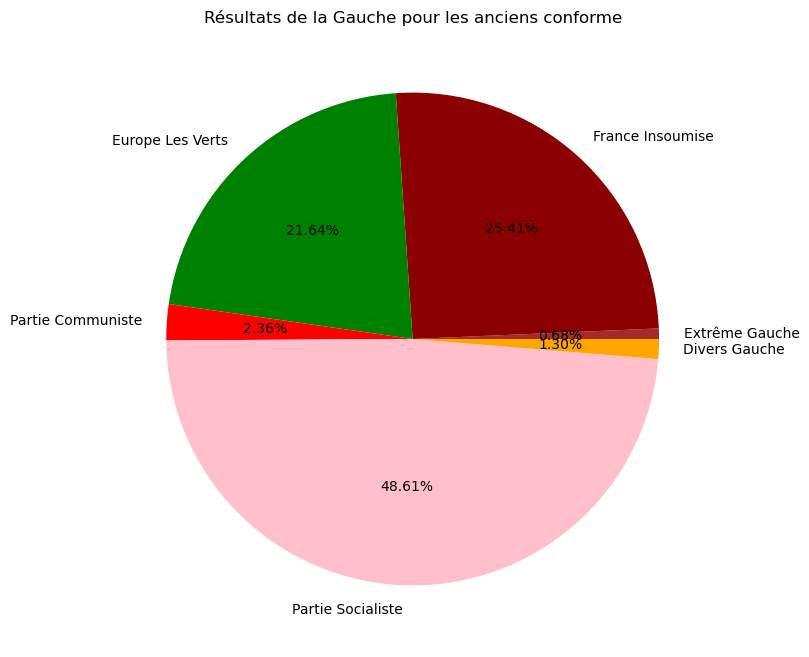

In [25]:
##Diagramme circulaire

plt.figure(figsize=(10,8))
plt.pie(conforme_G,labels = ["Extrême Gauche","France Insoumise","Europe Les Verts","Partie Communiste","Partie Socialiste","Divers Gauche"],
        colors = ['brown','darkred','green','red','pink','orange'],autopct = '%.2f%%')
plt.title("Résultats de la Gauche pour les anciens conforme")
plt.savefig("eur24_G_conforme.png")

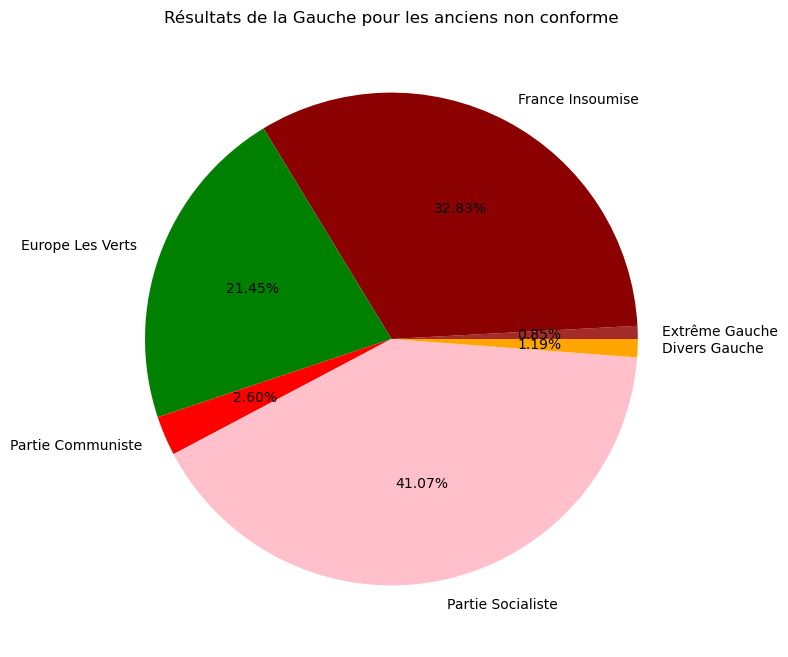

In [26]:
#Ancien non-conforme

plt.figure(figsize=(10,8))
plt.pie(non_conforme_G,labels = ["Extrême Gauche","France Insoumise","Europe Les Verts","Partie Communiste","Partie Socialiste","Divers Gauche"],
        colors = ['brown','darkred','green','red','pink','orange'],autopct = '%.2f%%')
plt.title("Résultats de la Gauche pour les anciens non conforme")
plt.savefig("eur24_G_non_conforme.png")

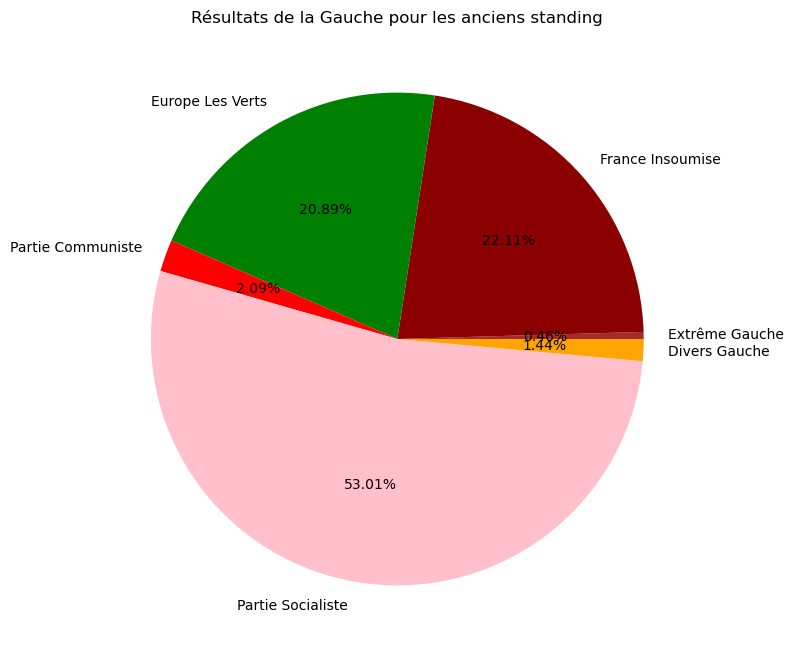

In [27]:
plt.figure(figsize=(10,8))
plt.pie(standing_G,labels = ["Extrême Gauche","France Insoumise","Europe Les Verts","Partie Communiste","Partie Socialiste","Divers Gauche"],
        colors = ['brown','darkred','green','red','pink','orange'],autopct = '%.2f%%')
plt.title("Résultats de la Gauche pour les anciens standing")
plt.savefig("eur24_G_standing.png")

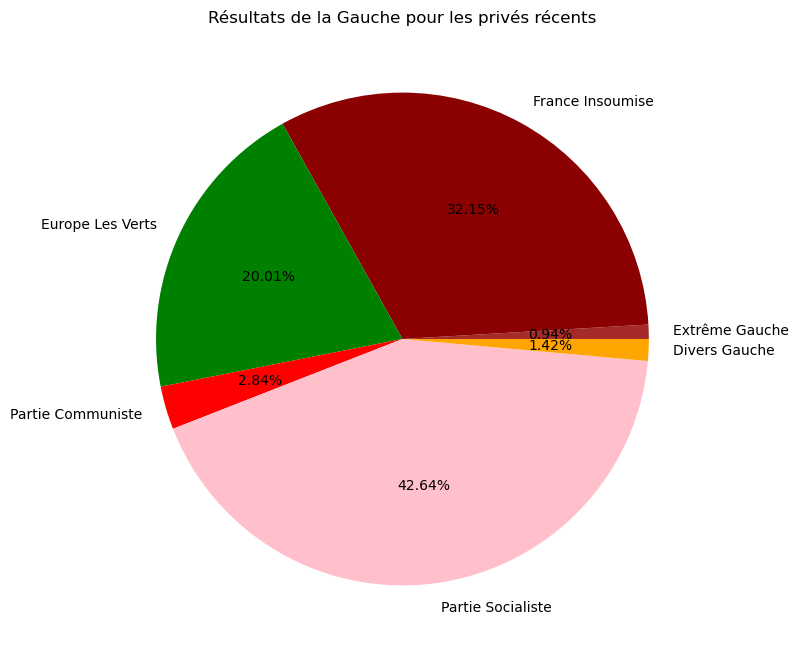

In [28]:
plt.figure(figsize=(10,8))
plt.pie(prive_G,labels = ["Extrême Gauche","France Insoumise","Europe Les Verts","Partie Communiste","Partie Socialiste","Divers Gauche"],
        colors = ['brown','darkred','green','red','pink','orange'],autopct = '%.2f%%')
plt.title("Résultats de la Gauche pour les privés récents")
plt.savefig("eur24_G_prive.png")

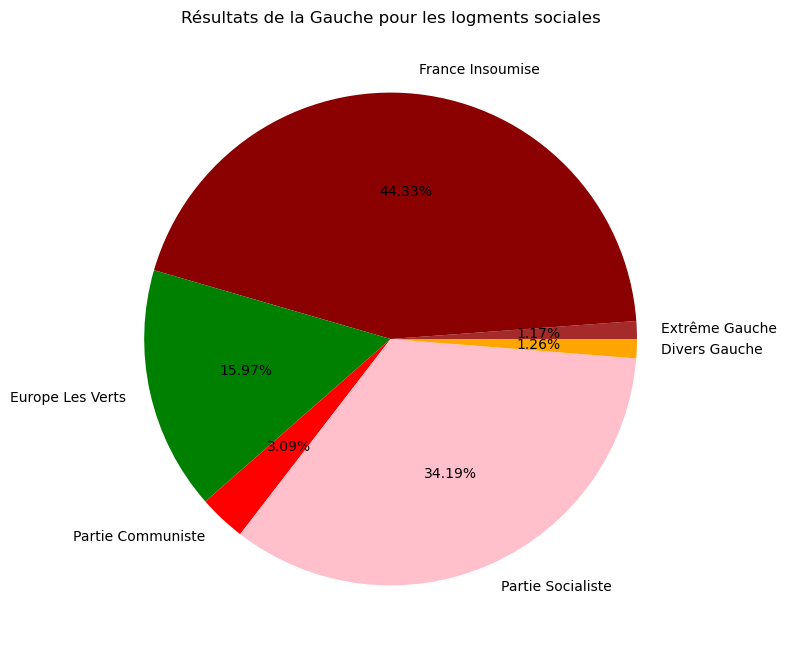

In [29]:
# Logement sociale

plt.figure(figsize=(10,8))
plt.pie(social_G,labels = ["Extrême Gauche","France Insoumise","Europe Les Verts","Partie Communiste","Partie Socialiste","Divers Gauche"],
        colors = ['brown','darkred','green','red','pink','orange'],autopct = '%.2f%%')
plt.title("Résultats de la Gauche pour les logments sociales")
plt.savefig("eur24_G_sociale.png")

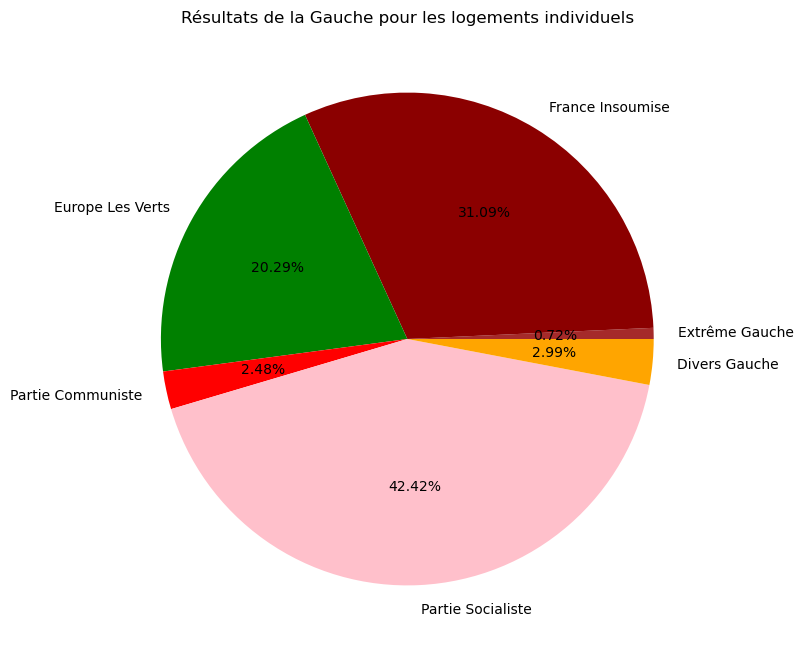

In [30]:
#logement individuel

plt.figure(figsize=(10,8))
plt.pie(individuel_G,labels = ["Extrême Gauche","France Insoumise","Europe Les Verts","Partie Communiste","Partie Socialiste","Divers Gauche"],
        colors = ['brown','darkred','green','red','pink','orange'],autopct = '%.2f%%')
plt.title("Résultats de la Gauche pour les logements individuels")
plt.savefig("eur24_G_indivuduel.png")


plt.show()



#### Analyse bivarié avec l'electorats de gauche

##### Prix immobiliés

In [31]:
gauche_logement.columns

Index(['habitat_principal', 'statut_logSocial', 'pour_logSocial',
       'pourct_T1/T2', 'prix_immo_m2', 'total_G_EUR', 'total_G_LEG',
       'ecart_voix_G', 'p_G_EUR', 'p_G_LEG', 'nb_PS', 'nb_EELV', 'nb_PCF',
       'nb_LFI', 'autresGauche', 'ExtGauche', 'partie_dominant'],
      dtype='object')

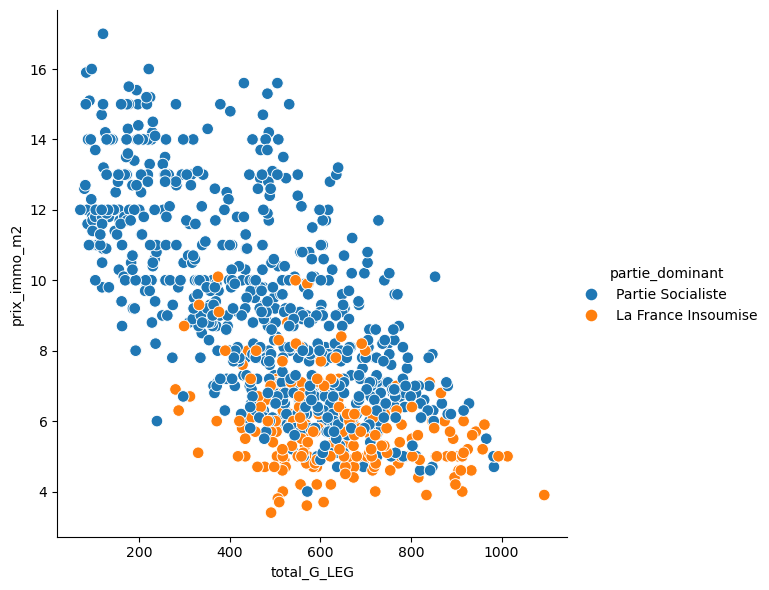

In [32]:
sns.relplot(x="total_G_LEG",y="prix_immo_m2",hue="partie_dominant",data=gauche_logement,height=6,s=70) ; plt.show()

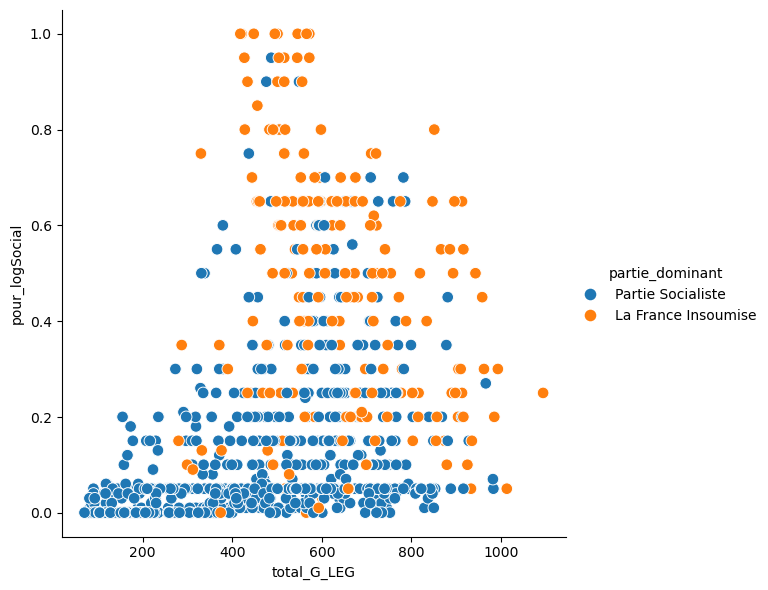

In [33]:
#Poucentage de logment sociale

sns.relplot(x="total_G_LEG",y="pour_logSocial",hue="partie_dominant",data=gauche_logement,height=6,s=70) ; plt.show()

In [34]:
### Tableau de contingence

tab_G_log = pd.crosstab(gauche_logement['partie_dominant'],gauche_logement['habitat_principal'],margins=False)
tab_G_log

habitat_principal,ancien_conforme,ancien_non_conforme,ancien_standing,individuel,logement_social,privé récent
partie_dominant,,,,,,
La France Insoumise,10,53,0,1,99,37
Partie Socialiste,262,128,97,6,52,156


##### Test de KHI-2

In [35]:
from scipy.stats import chi2_contingency as chi2_contingency

khi2, pval , ddl , contingent_theorique = chi2_contingency(tab_G_log)

In [36]:
khi2

252.66161785522635

In [37]:
pval

1.475709437623278e-52

In [38]:
ddl

5

In [39]:
pd.DataFrame(contingent_theorique)

,0,1,2,3,4,5
0,60.377358,40.17758,21.531632,1.553829,33.518313,42.841287
1,211.622642,140.82242,75.468368,5.446171,117.481687,150.158713


In [141]:
### Mesure de Cramér

# n = total des effectifs observés
n = tab_G_log.sum().sum()  

# paramètres
chi2 = 264.1
r, c = tab_G_log.shape
v_cramer = np.sqrt(chi2 / (n * (min(r-1, c-1))))

print("V de Cramér =", v_cramer)



V de Cramér = 0.5414044301044617


## 2-2 Electorat de droite 

In [40]:
# Resultats des européennes

droite =  pd.read_csv('res_droite.csv',sep=';',encoding='ISO-8859-1')

droite = droite.rename(columns = {'ï»¿id_bv':'id_bv'})

droite = droite.set_index('id_bv',drop='True')

#Fusion de données avec les données des logements
droite_logement = logement.merge(droite,on='id_bv')

droite_logement.head(10)

,habitat_principal,statut_logSocial,pour_logSocial,pourct_T1/T2,prix_immo_m2,v_D_EUR,p_D_EUR,v_D_LEG,p_D_LEG,ecart_D,nb_LR,nb_RN,nb_Rec,nb_autreDroite,nb_extDroite,partie_dominant
id_bv,,,,,,,,,,,,,,,,
01_01,ancien_standing,déficit,0.01,0.20,12.7,188,"0,2942",166,"0,2147",-22,72,60,42,2,12,Les RÃ©publicains
01_02,ancien_non_conforme,déficit,0.05,0.65,13.0,154,"0,2245",164,"0,1832",10,54,54,37,2,7,Les RÃ©publicains
01_03,ancien_conforme,déficit,0.05,0.80,10.0,183,"0,2447",195,"0,2252",12,58,71,37,0,17,Rassemblement National
01_04,ancien_conforme,déficit,0.05,0.80,10.3,175,"0,2391",151,"0,1678",-24,51,69,34,1,20,Rassemblement National
01_05,ancien_conforme,conforme,0.30,0.80,9.5,153,"0,2376",138,"0,1687",-15,44,53,41,3,12,Rassemblement National
01_06,ancien_non_conforme,déficit,0.05,0.65,11.0,230,"0,2934",198,"0,2185",-32,92,85,42,2,9,Les RÃ©publicains
01_07,ancien_conforme,déficit,0.05,0.65,14.0,217,"0,301",171,"0,2122",-46,89,66,43,4,15,Les RÃ©publicains
01_08,ancien_conforme,déficit,0.05,0.65,13.0,202,"0,364",185,"0,2753",-17,97,51,44,1,9,Les RÃ©publicains
01_09,ancien_non_conforme,déficit,0.05,0.65,12.5,226,"0,3897",188,"0,2831",-38,109,44,64,2,7,Les RÃ©publicains


On slipt les données par leurs natures des habitations

In [41]:
#Ancien conforme
droite_conforme = droite_logement[droite_logement['habitat_principal'] == 'ancien_conforme']

#Ancien non conforme
droite_non_conforme = droite_logement[droite_logement['habitat_principal'] == 'ancien_non_conforme']

#Ancien standing
droite_standing = droite_logement[droite_logement['habitat_principal'] == 'ancien_standing']

#Résidence privé récent
droite_prive = droite_logement[droite_logement['habitat_principal'] == 'privé récent']

#Logement sociale 
droite_social = droite_logement[droite_logement['habitat_principal'] == 'logement_social']

#individuel 
droite_individuel = droite_logement[droite_logement['habitat_principal'] == 'individuel']


In [42]:
## ancien conforme 

conforme_voixD = np.sum(droite_conforme['ecart_D'])

#Ancien non conforme
non_conforme_voixD = np.sum(droite_non_conforme['ecart_D'])

#Ancien standing
standing_voixD = np.sum(droite_standing['ecart_D'])

#Résidence privé récent
prive_voixD = np.sum(droite_prive['ecart_D'])

#Logement sociale 
social_voixD = np.sum(droite_social['ecart_D'])

#individuel 
individuel_voixD = np.sum(droite_individuel['ecart_D'])


In [43]:
ecartD = [conforme_voixD,non_conforme_voixD,standing_voixD,prive_voixD,social_voixD,individuel_voixD]

ecartD

[-6860, -2116, -3615, -3755, 242, -141]

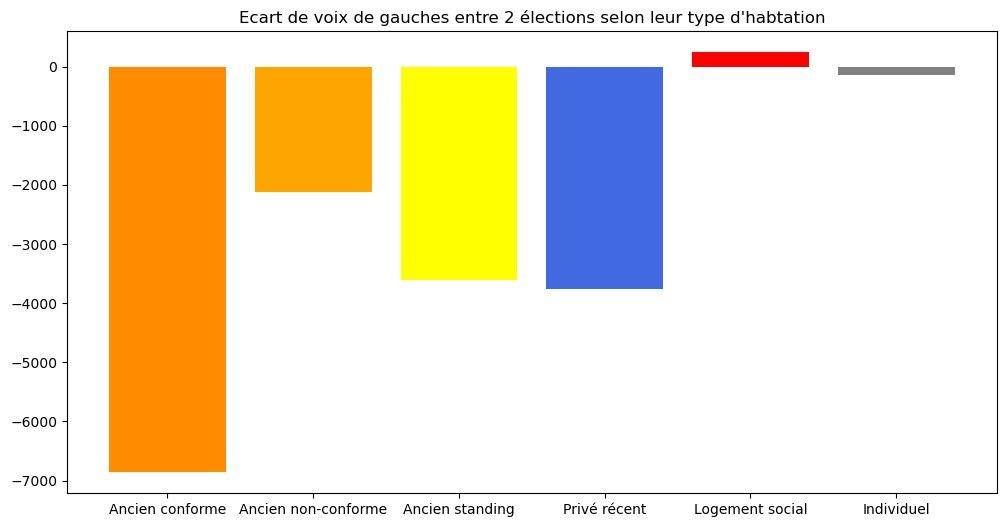

In [44]:
# Diagramme en barre 

plt.figure(figsize=(12,6))

names = ['Ancien conforme','Ancien non-conforme','Ancien standing','Privé récent','Logement social','Individuel']

plt.bar(names,ecartD,color = ['darkorange','orange','yellow','royalblue','red','grey']) 
plt.title("Ecart de voix de gauches entre 2 élections selon leur type d'habtation")


plt.savefig("ecart_D_log.png")

plt.show()

In [45]:
droite.columns

Index(['v_D_EUR', ' p_D_EUR ', 'v_D_LEG', ' p_D_LEG', 'ecart_D', 'nb_LR',
       'nb_RN', 'nb_Rec', 'nb_autreDroite', 'nb_extDroite', 'partie_dominant'],
      dtype='object')

#### Analyse par parties politiques 



In [46]:
# Ancien conforme

conforme_D = [np.sum(droite_conforme['nb_LR']),
              np.sum(droite_conforme['nb_RN']),
              np.sum(droite_conforme['nb_Rec']),
              np.sum(droite_conforme['nb_extDroite']),
              np.sum(droite_conforme['nb_autreDroite'])]


# Ancien non-conforme

non_conforme_D = [np.sum(droite_non_conforme['nb_LR']),
                  np.sum(droite_non_conforme['nb_RN']),
                  np.sum(droite_non_conforme['nb_Rec']),
                  np.sum(droite_non_conforme['nb_extDroite']),
                  np.sum(droite_non_conforme['nb_autreDroite'])]


# Ancien standing

standing_D = [np.sum(droite_standing['nb_LR']),
              np.sum(droite_standing['nb_RN']),
              np.sum(droite_standing['nb_Rec']),
              np.sum(droite_standing['nb_extDroite']),
              np.sum(droite_standing['nb_autreDroite'])]



# Privé récent

prive_D = [np.sum(droite_prive['nb_LR']),
           np.sum(droite_prive['nb_RN']),
           np.sum(droite_prive['nb_Rec']),
           np.sum(droite_prive['nb_extDroite']),
           np.sum(droite_prive['nb_autreDroite'])]


# Logement social

social_D = [np.sum(droite_social['nb_LR']),
            np.sum(droite_social['nb_RN']),
            np.sum(droite_social['nb_Rec']),
            np.sum(droite_social['nb_extDroite']),
            np.sum(droite_social['nb_autreDroite'])]


# Individuel

individuel_D = [np.sum(droite_individuel['nb_LR']),
                np.sum(droite_individuel['nb_RN']),
                np.sum(droite_individuel['nb_Rec']),
                np.sum(droite_individuel['nb_extDroite']),
                np.sum(droite_individuel['nb_autreDroite'])]




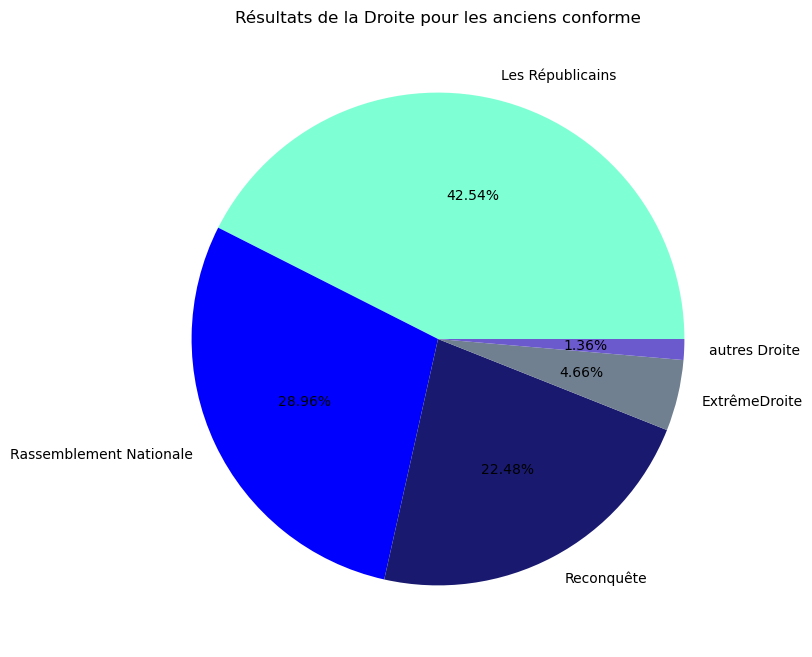

In [47]:
##Diagramme circulaire

plt.figure(figsize=(10,8))
plt.pie(conforme_D,labels = ["Les Républicains","Rassemblement Nationale","Reconquête","ExtrêmeDroite","autres Droite"],
        colors = ['aquamarine','blue','midnightblue','slategrey','slateblue'],autopct = '%.2f%%')
plt.title("Résultats de la Droite pour les anciens conforme")
plt.savefig("eur24_D_conforme.png")

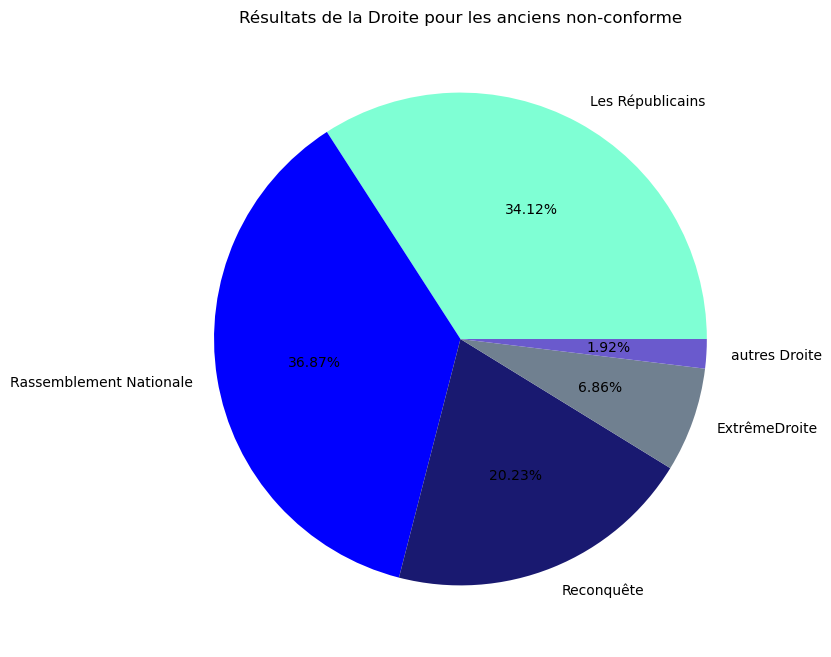

In [48]:
##Diagramme circulaire

plt.figure(figsize=(10,8))
plt.pie(non_conforme_D,labels = ["Les Républicains","Rassemblement Nationale","Reconquête","ExtrêmeDroite","autres Droite"],
        colors = ['aquamarine','blue','midnightblue','slategrey','slateblue'],autopct = '%.2f%%')
plt.title("Résultats de la Droite pour les anciens non-conforme")
plt.savefig("eur24_D_non_conforme.png")

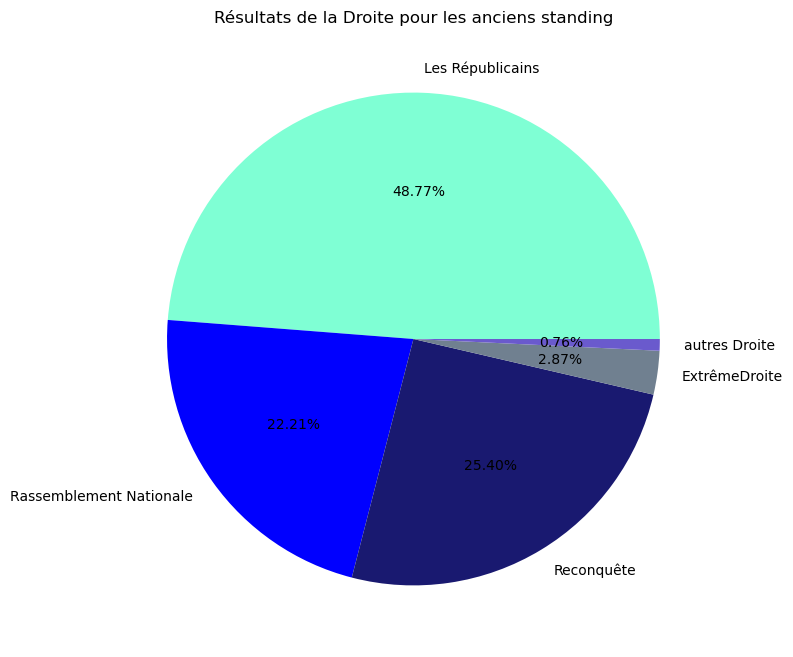

In [49]:
##Diagramme circulaire

plt.figure(figsize=(10,8))
plt.pie(standing_D,labels = ["Les Républicains","Rassemblement Nationale","Reconquête","ExtrêmeDroite","autres Droite"],
        colors = ['aquamarine','blue','midnightblue','slategrey','slateblue'],autopct = '%.2f%%')
plt.title("Résultats de la Droite pour les anciens standing")
plt.savefig("eur24_D_standing.png")

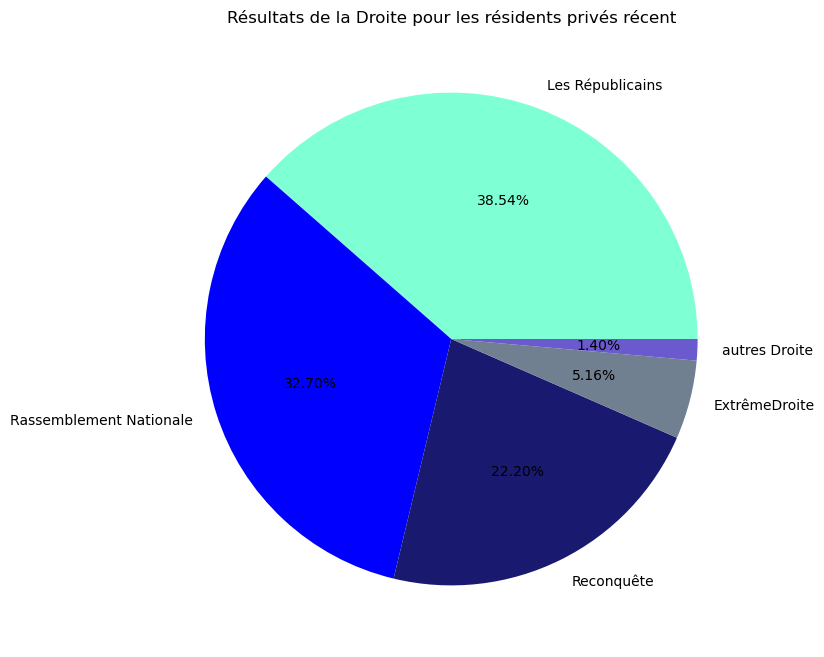

In [50]:
##Diagramme circulaire

plt.figure(figsize=(10,8))
plt.pie(prive_D,labels = ["Les Républicains","Rassemblement Nationale","Reconquête","ExtrêmeDroite","autres Droite"],
        colors = ['aquamarine','blue','midnightblue','slategrey','slateblue'],autopct = '%.2f%%')
plt.title("Résultats de la Droite pour les résidents privés récent")
plt.savefig("eur24_D_prive.png")

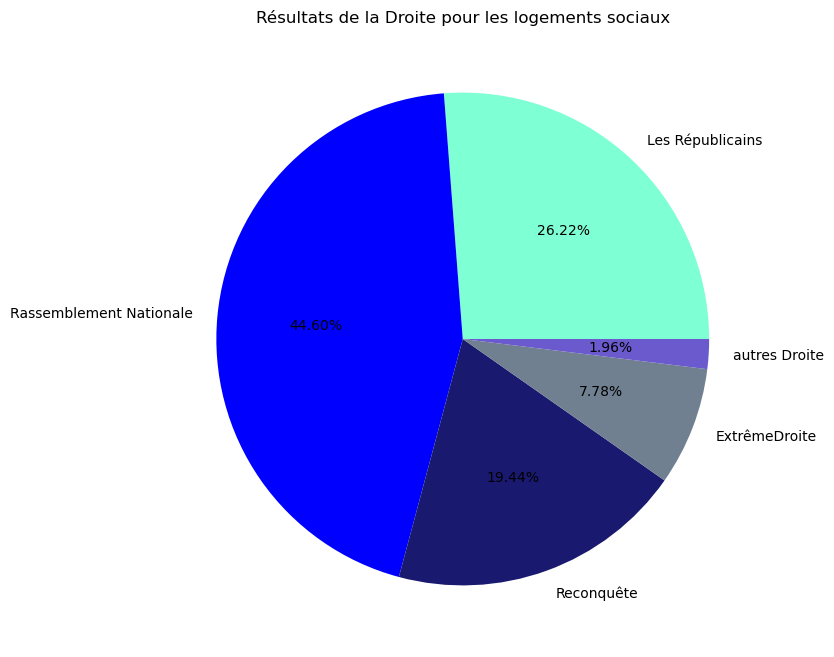

In [51]:
##Diagramme circulaire

plt.figure(figsize=(10,8))
plt.pie(social_D,labels = ["Les Républicains","Rassemblement Nationale","Reconquête","ExtrêmeDroite","autres Droite"],
        colors = ['aquamarine','blue','midnightblue','slategrey','slateblue'],autopct = '%.2f%%')
plt.title("Résultats de la Droite pour les logements sociaux")
plt.savefig("eur24_D_social.png")

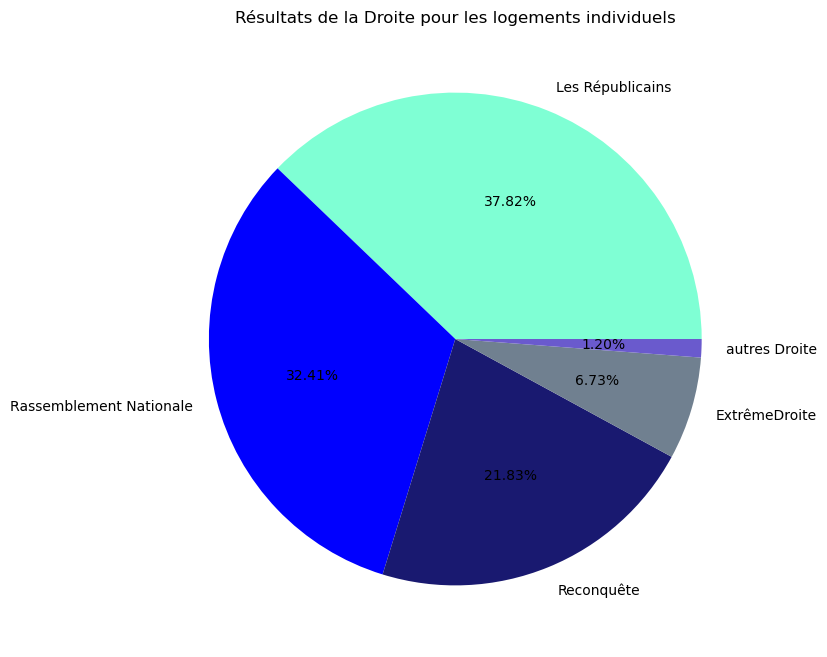

In [52]:
##Diagramme circulaire

plt.figure(figsize=(10,8))
plt.pie(individuel_D,labels = ["Les Républicains","Rassemblement Nationale","Reconquête","ExtrêmeDroite","autres Droite"],
        colors = ['aquamarine','blue','midnightblue','slategrey','slateblue'],autopct = '%.2f%%')
plt.title("Résultats de la Droite pour les logements individuels")
plt.savefig("eur24_D_indviduel.png")

##### Lien entre parties politiques et type de logments 

In [53]:
### Tableau de contingence

tab_D_log = pd.crosstab(droite_logement['partie_dominant'],droite_logement['habitat_principal'],margins=False)
tab_D_log

habitat_principal,ancien_conforme,ancien_non_conforme,ancien_standing,individuel,logement_social,privé récent
partie_dominant,,,,,,
Les RÃ©publicains,204,65,95,3,16,99
Rassemblement National,67,116,2,4,134,93
ReconquÃªte,1,0,0,0,1,1


##### Test de KHI-2

In [54]:
#### Test statistiques 


from scipy.stats import chi2_contingency as chi2_contingency

khi2, pval , ddl , contingent_theorique = chi2_contingency(tab_D_log)

In [55]:
khi2 

264.11865834130003

In [56]:
pval

5.80070493186138e-51

In [57]:
ddl

10

In [58]:
pd.DataFrame(contingent_theorique)

,0,1,2,3,4,5
0,145.509434,96.827969,51.891232,3.744728,80.779134,103.247503
1,125.584906,83.569367,44.785794,3.231964,69.718091,89.109878
2,0.905660,0.602664,0.322974,0.023307,0.502775,0.642619


In [140]:
### Mesure de Cramér

# n = total des effectifs observés
n = tab_D_log.sum().sum()  

# paramètres
chi2 = 264.1
r, c = tab_D_log.shape
v_cramer = np.sqrt(chi2 / (n * (min(r-1, c-1))))

print("V de Cramér =", v_cramer)



V de Cramér = 0.3828307438913031


# 2 - Commerce des parisiens

Pour cette deuxième partie on s'intérrèsse aux commerces parisiens , le but est d'analyser les électorats de gauches et e droite en fonction de type de commenrce qu'on y trouve pour chaque bureau de vote 

On ouvre le fichiers des commerces  



In [59]:
commerce = pd.read_csv("commerce.csv",sep=";",encoding="ISO-8859-1")

commerce = commerce.rename(columns = {'ID Bureau': 'id_bv'})


commerce.head(5)

,id_bv,Type_centralités,type_commerce,densité
0,01_01,infra-métropolitaines,luxe,moyenne
1,01_02,infra-métropolitaines,proximités,forte
2,01_03,métropolitaine,ludiques,forte
3,01_04,métropolitaine,ludiques,forte
4,01_05,métropolitaine,diversifié,forte


## 2-1 Analyse globales

On analyser les type de commerce ainsi de leurs natures de centralités 

In [60]:
commerce["Type_centralités"].value_counts()

Type_centralités
infra-métropolitaines    784
métropolitaine           117
Name: count, dtype: int64

In [61]:
commerce["type_commerce"].value_counts()

type_commerce
peu commerciale    299
proximités         297
agglomération      185
diversifié          67
populaire           29
luxe                13
ludiques            10
antiquaire           1
Name: count, dtype: int64

In [62]:
commerce["densité"].value_counts()

densité
moyenne    588
faible     215
forte       98
Name: count, dtype: int64

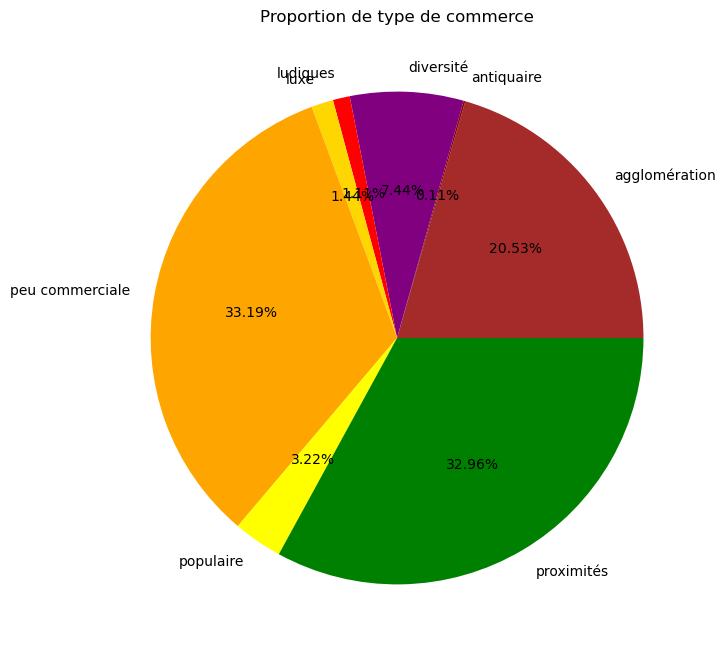

In [63]:
type_commerce = [185,1,67,10,13,299,29,297] 

nom_commerce = ["agglomération","antiquaire","diversité","ludiques","luxe","peu commerciale","populaire","proximités"]


plt.figure(figsize=(12,8))


plt.pie(type_commerce,labels = nom_commerce, colors = ['brown','darkred','purple','red','gold','orange','yellow','green'],autopct = '%.2f%%')
plt.title("Proportion de type de commerce")
plt.savefig("type_commerce_pie.png")

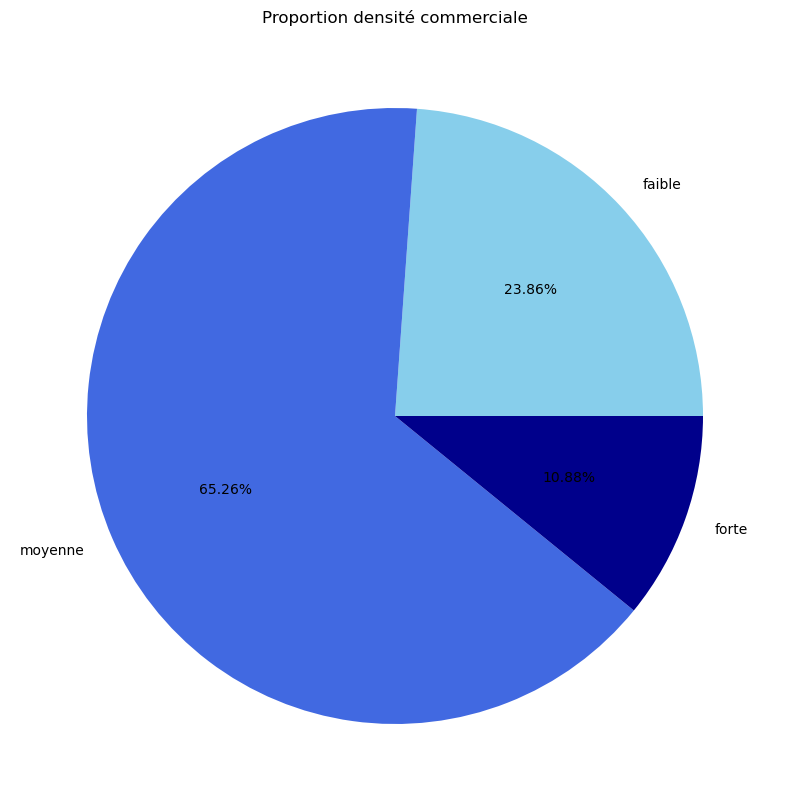

In [64]:
#Type de centralité

type_densite = [215,588,98] 

nom_densite = ["faible","moyenne","forte"]


plt.figure(figsize=(15,10))


plt.pie(type_densite,labels = nom_densite, colors = ['skyblue','royalblue','darkblue'],autopct = '%.2f%%')
plt.title("Proportion densité commerciale")
plt.savefig("type_densite_com_pie.png")

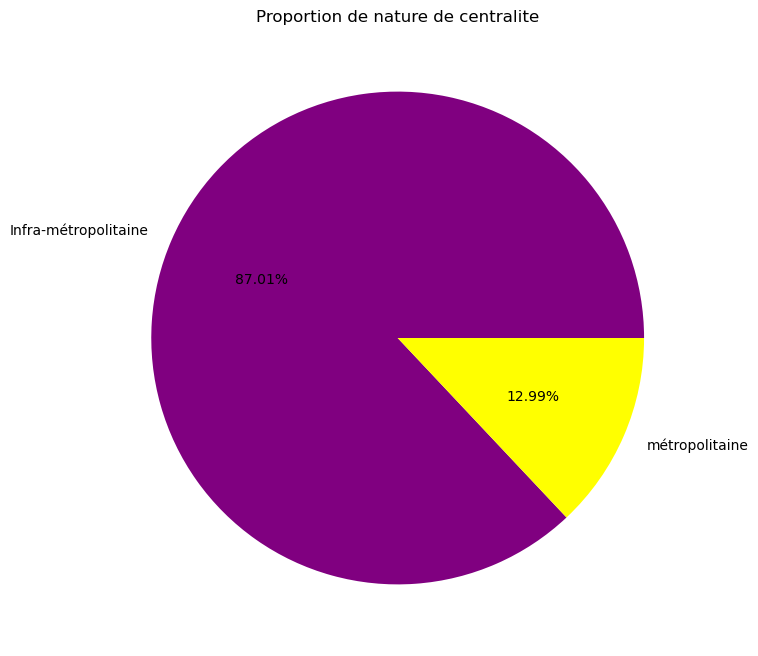

In [65]:
#Type de centralité

type_centralite = [784,117] 

nom_centralite = ["Infra-métropolitaine","métropolitaine"]


plt.figure(figsize=(12,8))


plt.pie(type_centralite,labels = nom_centralite, colors = ['purple','yellow'],autopct = '%.2f%%')
plt.title("Proportion de nature de centralite")
plt.savefig("type_centralite_pie.png")

## 2-2 Analyse des resultats des bureaux de vote


On va analyser les type de commerce en fonction des résultats des deux éléctions 

In [66]:
#Fusionner les données avec les résultats des européennes


commerce_eur = commerce.merge(eur24,on='id_bv')

commerce_eur = commerce_eur.set_index('id_bv',drop='True')

In [67]:
commerce_eur.head(5)

,Type_centralités,type_commerce,densité,nb_procu,nb_inscr,nb_abscent,taux_ab,nb_emarg,nb_votant,nb_blanc_null,nb_exprim,NB_ExtGauche,NB_Gauche,NB_Centre,NB_Droite,NB_ExtDroite,NB_Divers,eur_pol_dominant
id_bv,,,,,,,,,,,,,,,,,,
01_01,infra-métropolitaines,luxe,moyenne,37,1099,456,0.4149,643,643,4,639,0,157,144,72,114,14,Gauche
01_02,infra-métropolitaines,proximités,forte,59,1232,537,0.4359,695,695,9,686,1,157,193,54,100,10,Centre
01_03,métropolitaine,ludiques,forte,56,1225,468,0.3820,756,757,9,748,1,188,177,58,125,19,Gauche
01_04,métropolitaine,ludiques,forte,48,1310,569,0.4344,741,741,9,732,3,211,146,51,124,21,Gauche
01_05,métropolitaine,diversifié,forte,48,1090,444,0.4073,647,646,2,644,1,164,149,44,108,5,Gauche


In [68]:
##### Fusionner les données avec les résultats des legislative

commerce_leg = commerce.merge(leg24,on='id_bv')

commerce_leg = commerce_leg.set_index('id_bv',drop='True')

commerce_leg.head(5)

,Type_centralités,type_commerce,densité,num_circo,nb_procu,nb_inscr,nb_emarg,nb_votant,nb_bl,nb_nul,nb_exprim,NB_ExtGauche,NB_Gauche,NB_Centre,NB_Droite,NB_ExtDroite,NB_Divers
id_bv,,,,,,,,,,,,,,,,,
01_01,infra-métropolitaines,luxe,moyenne,1,129,1080,781,781,7,1,773,3,279,324,70,96,1
01_02,infra-métropolitaines,proximités,forte,1,137,1211,904,904,5,4,895,0,312,414,73,91,5
01_03,métropolitaine,ludiques,forte,1,140,1211,874,874,3,5,866,8,315,346,65,130,2
01_04,métropolitaine,ludiques,forte,1,133,1295,912,912,7,5,900,18,416,315,45,106,0
01_05,métropolitaine,diversifié,forte,1,145,1077,823,823,3,2,818,1,320,356,56,82,3


#### Commerce d'agglomération 



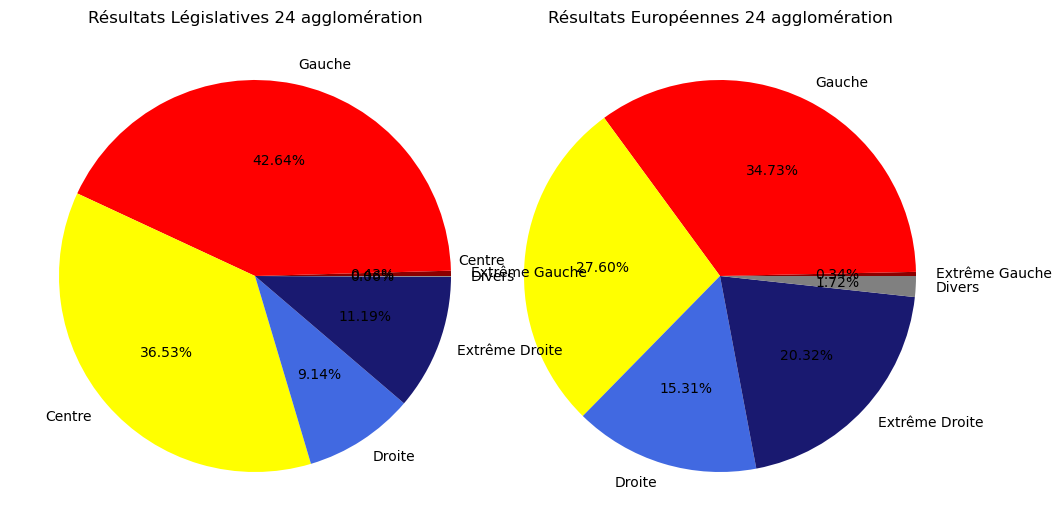

In [72]:
# Européennes

agglomeration_eur = commerce_eur[commerce_eur["type_commerce"] == "agglomération"]


res_agglomeration_eur = [np.sum(agglomeration_eur['NB_ExtGauche']),
                         np.sum(agglomeration_eur['NB_Gauche']),
                         np.sum(agglomeration_eur['NB_Centre']),
                         np.sum(agglomeration_eur['NB_Droite']),
                         np.sum(agglomeration_eur['NB_ExtDroite']),
                         np.sum(agglomeration_eur['NB_Divers'])]


#Legislative

agglomeration_leg = commerce_leg[commerce_leg["type_commerce"] == "agglomération"]


res_agglomeration_leg = [np.sum(agglomeration_leg['NB_ExtGauche']),
                      np.sum(agglomeration_leg['NB_Gauche']),
                      np.sum(agglomeration_leg['NB_Centre']),
                      np.sum(agglomeration_leg['NB_Droite']),
                      np.sum(agglomeration_leg['NB_ExtDroite']),
                      np.sum(agglomeration_leg['NB_Divers'])]


#Diagramme circulaire
plt.figure(figsize=(22,14))


plt.subplot(2,1,1)
plt.pie(res_agglomeration_eur,labels = ["Extrême Gauche","Gauche","Centre","Droite","Extrême Droite","Divers"],
        colors = ['darkred','red','yellow','royalblue','midnightblue','grey'],autopct = '%.2f%%')
plt.title("Résultats Européennes 24 agglomération")


plt.subplot(2,2,1)
plt.pie(res_agglomeration_leg,labels = ["Extrême Gauche","Gauche","Centre","Droite","Extrême Droite","Divers"],
        colors = ['darkred','red','yellow','royalblue','midnightblue','grey'],autopct = '%.2f%%')
plt.title("Résultats Législatives 24 agglomération")


plt.savefig("res24_agglomeration.png")

plt.show()

#### antiquaire


Commerçant qui achète et vend des objets anciens de qualité ou spécialiste d'histoire ancienne.


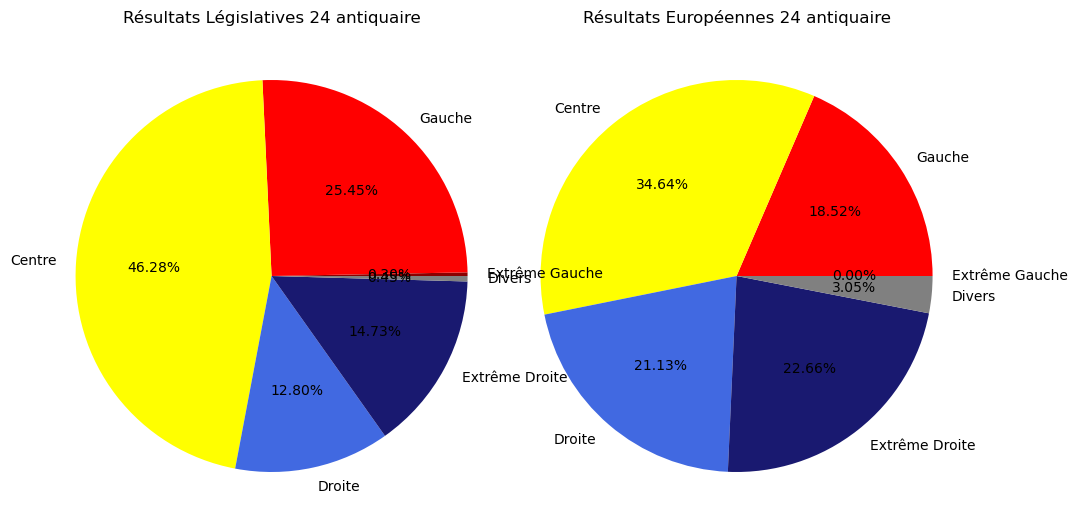

In [73]:
# Européennes

antiquaire_eur = commerce_eur[commerce_eur["type_commerce"] == "antiquaire"]


res_antiquaire_eur = [np.sum(antiquaire_eur['NB_ExtGauche']),
                         np.sum(antiquaire_eur['NB_Gauche']),
                         np.sum(antiquaire_eur['NB_Centre']),
                         np.sum(antiquaire_eur['NB_Droite']),
                         np.sum(antiquaire_eur['NB_ExtDroite']),
                         np.sum(antiquaire_eur['NB_Divers'])]


#Legislative

antiquaire_leg = commerce_leg[commerce_leg["type_commerce"] == "antiquaire"]


res_antiquaire_leg = [np.sum(antiquaire_leg['NB_ExtGauche']),
                      np.sum(antiquaire_leg['NB_Gauche']),
                      np.sum(antiquaire_leg['NB_Centre']),
                      np.sum(antiquaire_leg['NB_Droite']),
                      np.sum(antiquaire_leg['NB_ExtDroite']),
                      np.sum(antiquaire_leg['NB_Divers'])]


#Diagramme circulaire
plt.figure(figsize=(22,14))


plt.subplot(2,1,1)
plt.pie(res_antiquaire_eur,labels = ["Extrême Gauche","Gauche","Centre","Droite","Extrême Droite","Divers"],
        colors = ['darkred','red','yellow','royalblue','midnightblue','grey'],autopct = '%.2f%%')
plt.title("Résultats Européennes 24 antiquaire")



plt.subplot(2,2,1)
plt.pie(res_antiquaire_leg,labels = ["Extrême Gauche","Gauche","Centre","Droite","Extrême Droite","Divers"],
        colors = ['darkred','red','yellow','royalblue','midnightblue','grey'],autopct = '%.2f%%')
plt.title("Résultats Législatives 24 antiquaire")


plt.savefig("res24_antiquaire.png")

plt.show()

#### Commerce de diversité 

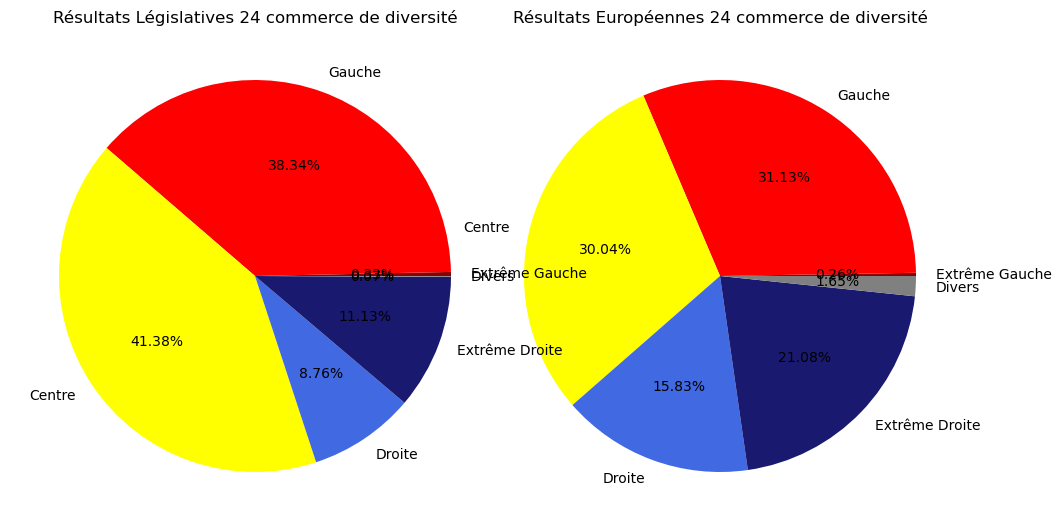

In [75]:
# Européennes

diversite_eur = commerce_eur[commerce_eur["type_commerce"] == "diversifié"]


res_diversite_eur = [np.sum(diversite_eur['NB_ExtGauche']),
                         np.sum(diversite_eur['NB_Gauche']),
                         np.sum(diversite_eur['NB_Centre']),
                         np.sum(diversite_eur['NB_Droite']),
                         np.sum(diversite_eur['NB_ExtDroite']),
                         np.sum(diversite_eur['NB_Divers'])]


#Legislative

diversite_leg = commerce_leg[commerce_leg["type_commerce"] == "diversifié"]


res_diversite_leg = [np.sum(diversite_leg['NB_ExtGauche']),
                     np.sum(diversite_leg['NB_Gauche']),
                     np.sum(diversite_leg['NB_Centre']),
                     np.sum(diversite_leg['NB_Droite']),
                     np.sum(diversite_leg['NB_ExtDroite']),
                     np.sum(diversite_leg['NB_Divers'])]


#Diagramme circulaire
plt.figure(figsize=(22,14))


plt.subplot(2,1,1)
plt.pie(res_diversite_eur,labels = ["Extrême Gauche","Gauche","Centre","Droite","Extrême Droite","Divers"],
        colors = ['darkred','red','yellow','royalblue','midnightblue','grey'],autopct = '%.2f%%')
plt.title("Résultats Européennes 24 commerce de diversité")


plt.subplot(2,2,1)
plt.pie(res_diversite_leg,labels = ["Extrême Gauche","Gauche","Centre","Droite","Extrême Droite","Divers"],
        colors = ['darkred','red','yellow','royalblue','midnightblue','grey'],autopct = '%.2f%%')
plt.title("Résultats Législatives 24 commerce de diversité")


          
plt.savefig("res24_diversite.png")

plt.show()

#### Commerce ludique 

Les activités ludiques sont ainsi des supports facilitateurs pour entrer en relation avec autrui, qu'il s'agisse d'une interaction entre l'enfant ou le jeune et l'animateur ou encore d'interactions entre pairs.

Un commerce d'interaction social

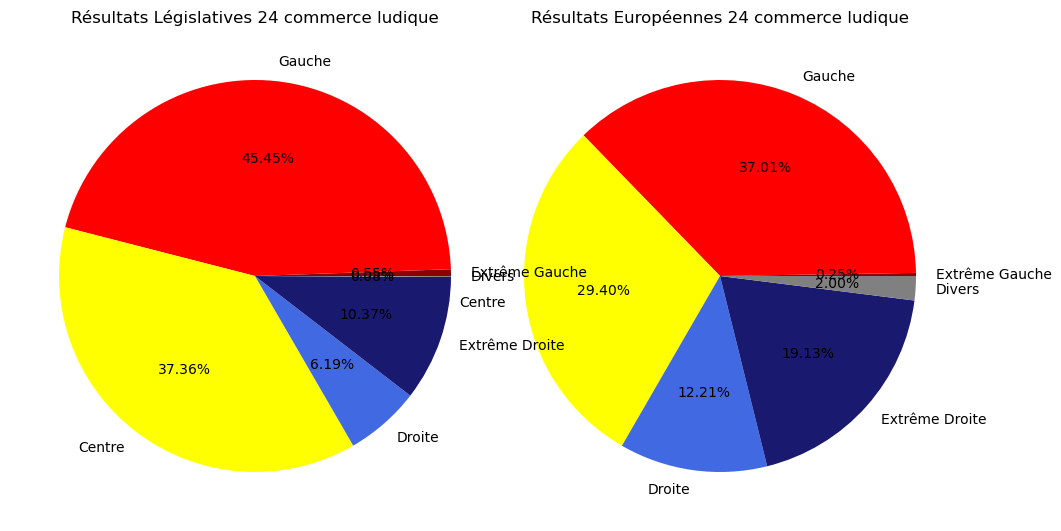

In [76]:
# Européennes

ludique_eur = commerce_eur[commerce_eur["type_commerce"] == "ludiques"]


res_ludique_eur = [np.sum(ludique_eur['NB_ExtGauche']),
                         np.sum(ludique_eur['NB_Gauche']),
                         np.sum(ludique_eur['NB_Centre']),
                         np.sum(ludique_eur['NB_Droite']),
                         np.sum(ludique_eur['NB_ExtDroite']),
                         np.sum(ludique_eur['NB_Divers'])]


#Legislative

ludique_leg = commerce_leg[commerce_leg["type_commerce"] == "ludiques"]


res_ludique_leg = [np.sum(ludique_leg['NB_ExtGauche']),
                     np.sum(ludique_leg['NB_Gauche']),
                     np.sum(ludique_leg['NB_Centre']),
                     np.sum(ludique_leg['NB_Droite']),
                     np.sum(ludique_leg['NB_ExtDroite']),
                     np.sum(ludique_leg['NB_Divers'])]


#Diagramme circulaire
plt.figure(figsize=(22,14))


plt.subplot(2,1,1)
plt.pie(res_ludique_eur,labels = ["Extrême Gauche","Gauche","Centre","Droite","Extrême Droite","Divers"],
        colors = ['darkred','red','yellow','royalblue','midnightblue','grey'],autopct = '%.2f%%')
plt.title("Résultats Européennes 24 commerce ludique")



plt.subplot(2,2,1)
plt.pie(res_ludique_leg,labels = ["Extrême Gauche","Gauche","Centre","Droite","Extrême Droite","Divers"],
        colors = ['darkred','red','yellow','royalblue','midnightblue','grey'],autopct = '%.2f%%')
plt.title("Résultats Législatives 24 commerce ludique")


plt.savefig("res24_ludique.png")

plt.show()

#### Commerce de luxe 

Commerce de vente de hautes valeurs 

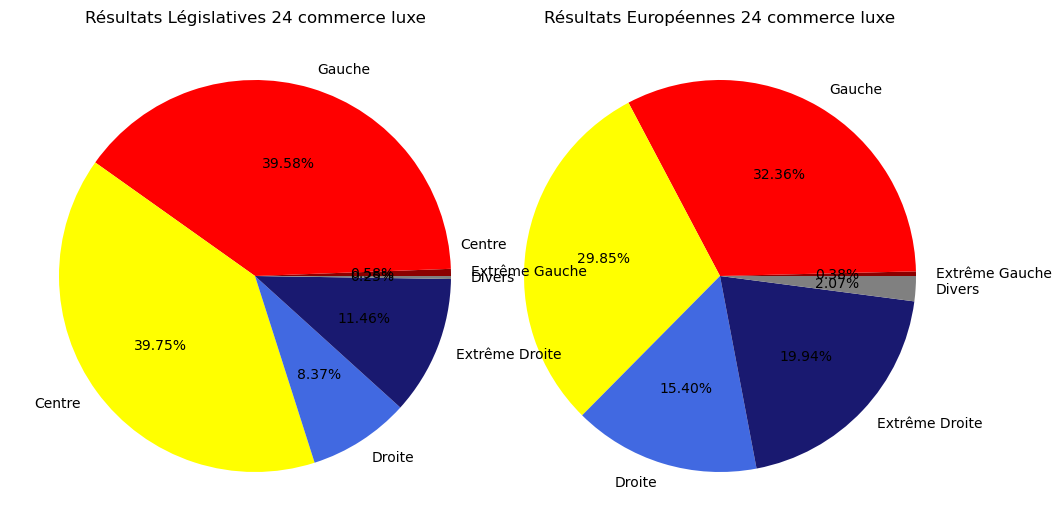

In [77]:
# Européennes

luxe_eur = commerce_eur[commerce_eur["type_commerce"] == "luxe"]


res_luxe_eur = [np.sum(luxe_eur['NB_ExtGauche']),
                         np.sum(luxe_eur['NB_Gauche']),
                         np.sum(luxe_eur['NB_Centre']),
                         np.sum(luxe_eur['NB_Droite']),
                         np.sum(luxe_eur['NB_ExtDroite']),
                         np.sum(luxe_eur['NB_Divers'])]


#Legislative

luxe_leg = commerce_leg[commerce_leg["type_commerce"] == "luxe"]


res_luxe_leg = [np.sum(luxe_leg['NB_ExtGauche']),
                     np.sum(luxe_leg['NB_Gauche']),
                     np.sum(luxe_leg['NB_Centre']),
                     np.sum(luxe_leg['NB_Droite']),
                     np.sum(luxe_leg['NB_ExtDroite']),
                     np.sum(luxe_leg['NB_Divers'])]


#Diagramme circulaire
plt.figure(figsize=(22,14))


plt.subplot(2,1,1)
plt.pie(res_luxe_eur,labels = ["Extrême Gauche","Gauche","Centre","Droite","Extrême Droite","Divers"],
        colors = ['darkred','red','yellow','royalblue','midnightblue','grey'],autopct = '%.2f%%')
plt.title("Résultats Européennes 24 commerce luxe")
plt.savefig("eur24_res_luxe.png")


plt.subplot(2,2,1)
plt.pie(res_luxe_leg,labels = ["Extrême Gauche","Gauche","Centre","Droite","Extrême Droite","Divers"],
        colors = ['darkred','red','yellow','royalblue','midnightblue','grey'],autopct = '%.2f%%')
plt.title("Résultats Législatives 24 commerce luxe")


plt.savefig("res24_luxe.png")

plt.show()

#### Commerce de proximité

Commerce de service au quotidien ou de premier nécessité 

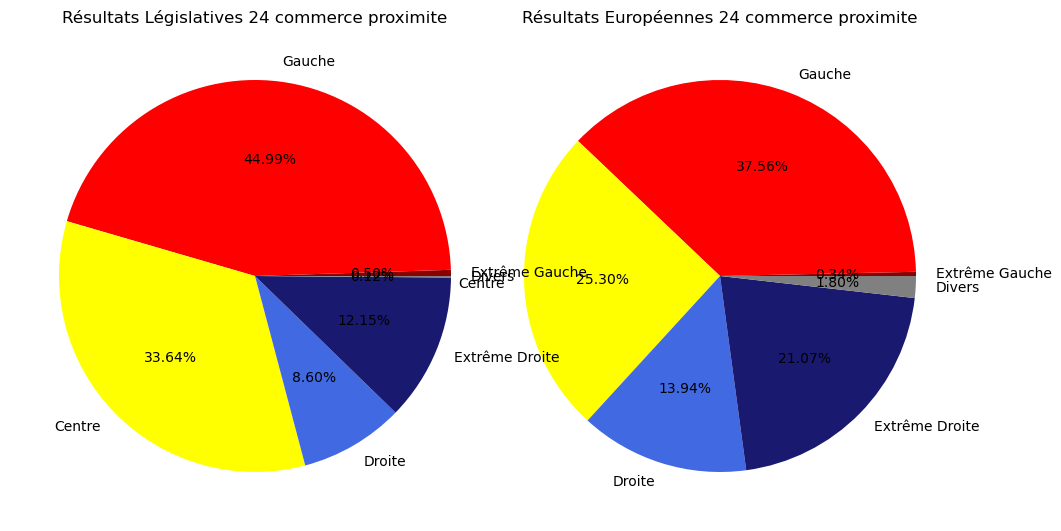

In [78]:
# Européennes

proximite_eur = commerce_eur[commerce_eur["type_commerce"] == "proximités"]


res_proximite_eur = [np.sum(proximite_eur['NB_ExtGauche']),
                         np.sum(proximite_eur['NB_Gauche']),
                         np.sum(proximite_eur['NB_Centre']),
                         np.sum(proximite_eur['NB_Droite']),
                         np.sum(proximite_eur['NB_ExtDroite']),
                         np.sum(proximite_eur['NB_Divers'])]


#Legislative

proximite_leg = commerce_leg[commerce_leg["type_commerce"] == "proximités"]


res_proximite_leg = [np.sum(proximite_leg['NB_ExtGauche']),
                     np.sum(proximite_leg['NB_Gauche']),
                     np.sum(proximite_leg['NB_Centre']),
                     np.sum(proximite_leg['NB_Droite']),
                     np.sum(proximite_leg['NB_ExtDroite']),
                     np.sum(proximite_leg['NB_Divers'])]


#Diagramme circulaire
plt.figure(figsize=(22,14))


plt.subplot(2,1,1)
plt.pie(res_proximite_eur,labels = ["Extrême Gauche","Gauche","Centre","Droite","Extrême Droite","Divers"],
        colors = ['darkred','red','yellow','royalblue','midnightblue','grey'],autopct = '%.2f%%')
plt.title("Résultats Européennes 24 commerce proximite")


plt.subplot(2,2,1)
plt.pie(res_proximite_leg,labels = ["Extrême Gauche","Gauche","Centre","Droite","Extrême Droite","Divers"],
        colors = ['darkred','red','yellow','royalblue','midnightblue','grey'],autopct = '%.2f%%')
plt.title("Résultats Législatives 24 commerce proximite")


plt.savefig("res24_proximite.png")

plt.show()

#### Commerce populaire

un ensemble de commerce attirant une forte quantité de personne

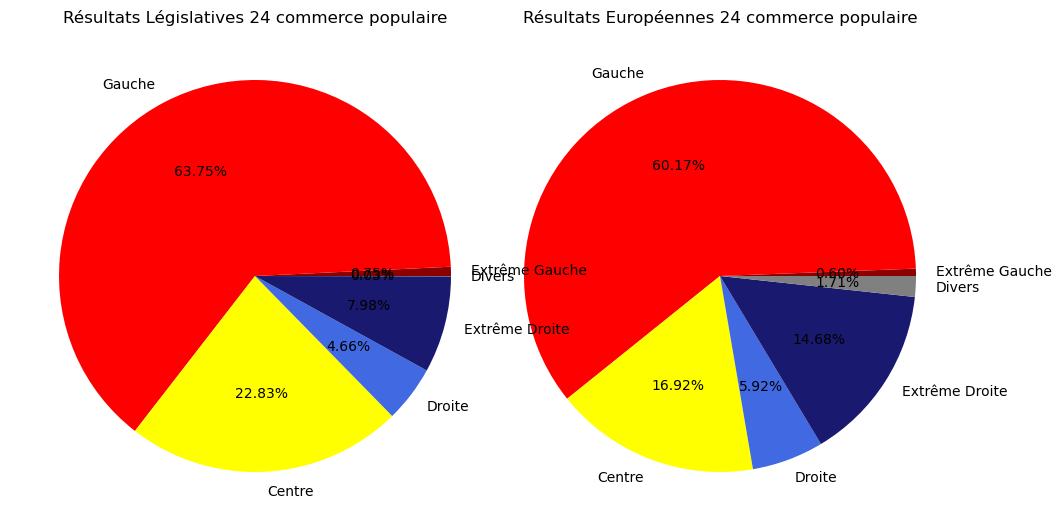

In [79]:
# Européennes

populaire_eur = commerce_eur[commerce_eur["type_commerce"] == "populaire"]


res_populaire_eur = [np.sum(populaire_eur['NB_ExtGauche']),
                         np.sum(populaire_eur['NB_Gauche']),
                         np.sum(populaire_eur['NB_Centre']),
                         np.sum(populaire_eur['NB_Droite']),
                         np.sum(populaire_eur['NB_ExtDroite']),
                         np.sum(populaire_eur['NB_Divers'])]


#Legislative

populaire_leg = commerce_leg[commerce_leg["type_commerce"] == "populaire"]


res_populaire_leg = [np.sum(populaire_leg['NB_ExtGauche']),
                     np.sum(populaire_leg['NB_Gauche']),
                     np.sum(populaire_leg['NB_Centre']),
                     np.sum(populaire_leg['NB_Droite']),
                     np.sum(populaire_leg['NB_ExtDroite']),
                     np.sum(populaire_leg['NB_Divers'])]


#Diagramme circulaire
plt.figure(figsize=(22,14))


plt.subplot(2,1,1)
plt.pie(res_populaire_eur,labels = ["Extrême Gauche","Gauche","Centre","Droite","Extrême Droite","Divers"],
        colors = ['darkred','red','yellow','royalblue','midnightblue','grey'],autopct = '%.2f%%')
plt.title("Résultats Européennes 24 commerce populaire")


plt.subplot(2,2,1)
plt.pie(res_populaire_leg,labels = ["Extrême Gauche","Gauche","Centre","Droite","Extrême Droite","Divers"],
        colors = ['darkred','red','yellow','royalblue','midnightblue','grey'],autopct = '%.2f%%')
plt.title("Résultats Législatives 24 commerce populaire")


plt.savefig("res24_populaire.png")

plt.show()

#### Lieux peu commerciales


On a certains bureau de vote où on a peu de commerce 

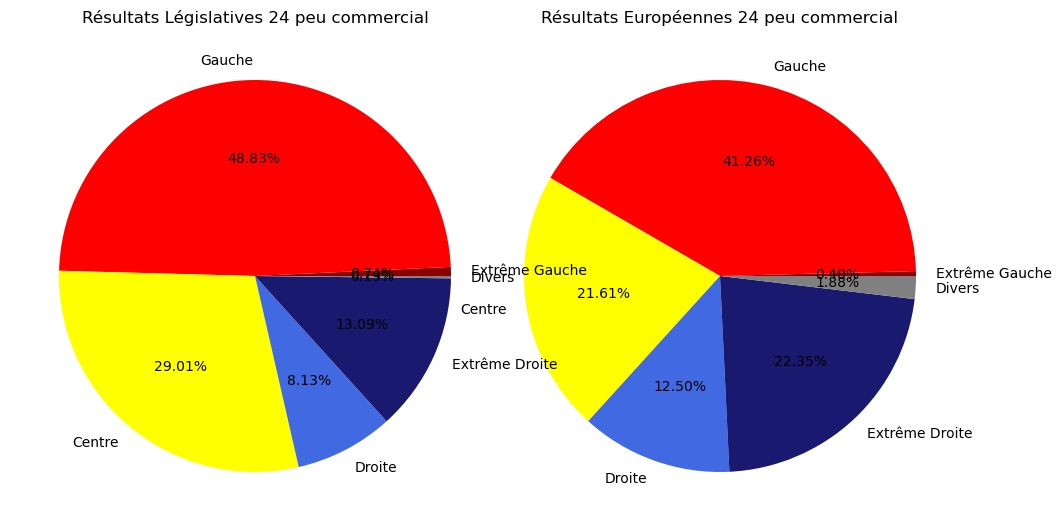

In [81]:
# Européennes

peu_commercial_eur = commerce_eur[commerce_eur["type_commerce"] == "peu commerciale"]


res_peu_commercial_eur = [np.sum(peu_commercial_eur['NB_ExtGauche']),
                         np.sum(peu_commercial_eur['NB_Gauche']),
                         np.sum(peu_commercial_eur['NB_Centre']),
                         np.sum(peu_commercial_eur['NB_Droite']),
                         np.sum(peu_commercial_eur['NB_ExtDroite']),
                         np.sum(peu_commercial_eur['NB_Divers'])]


#Legislative

peu_commercial_leg = commerce_leg[commerce_leg["type_commerce"] == "peu commerciale"]


res_peu_commercial_leg = [np.sum(peu_commercial_leg['NB_ExtGauche']),
                     np.sum(peu_commercial_leg['NB_Gauche']),
                     np.sum(peu_commercial_leg['NB_Centre']),
                     np.sum(peu_commercial_leg['NB_Droite']),
                     np.sum(peu_commercial_leg['NB_ExtDroite']),
                     np.sum(peu_commercial_leg['NB_Divers'])]


#Diagramme circulaire
plt.figure(figsize=(22,14))


plt.subplot(2,1,1)
plt.pie(res_peu_commercial_eur,labels = ["Extrême Gauche","Gauche","Centre","Droite","Extrême Droite","Divers"],
        colors = ['darkred','red','yellow','royalblue','midnightblue','grey'],autopct = '%.2f%%')
plt.title("Résultats Européennes 24 peu commercial")


plt.subplot(2,2,1)
plt.pie(res_peu_commercial_leg,labels = ["Extrême Gauche","Gauche","Centre","Droite","Extrême Droite","Divers"],
        colors = ['darkred','red','yellow','royalblue','midnightblue','grey'],autopct = '%.2f%%')
plt.title("Résultats Législatives 24 peu commercial")



plt.savefig("res24_peu_commercial.png")

plt.show()

## 2-3 Electorat de gauche dans le commerce

In [82]:
# Resultats des européennes

gauche =  pd.read_csv('res_gauche.csv',sep=';',encoding='ISO-8859-1')

gauche = gauche.rename(columns = {"ï»¿id_bv":"id_bv"})

gauche = gauche.set_index('id_bv',drop='True')

#Fusion de données avec les données des logements
gauche_commerce = gauche.merge(commerce,on='id_bv')

gauche_commerce = gauche_commerce.set_index('id_bv',drop='True')


gauche_commerce.head(10)

,total_G_EUR,total_G_LEG,ecart_voix_G,p_G_EUR,p_G_LEG,nb_PS,nb_EELV,nb_PCF,nb_LFI,autresGauche,ExtGauche,partie_dominant,Type_centralités,type_commerce,densité
id_bv,,,,,,,,,,,,,,,
01_01,295,282,-13,"0,4617","0,3648",136,66,4,84,3,2,Partie Socialiste,infra-métropolitaines,luxe,moyenne
01_02,329,312,-17,"0,4796","0,3486",171,72,5,71,9,1,Partie Socialiste,infra-métropolitaines,proximités,forte
01_03,369,323,-46,"0,4933","0,3730",178,86,11,86,5,3,Partie Socialiste,métropolitaine,ludiques,forte
01_04,390,434,44,"0,5328","0,4822",175,66,15,125,5,4,Partie Socialiste,métropolitaine,ludiques,forte
01_05,338,321,-17,"0,5248","0,3924",173,79,5,75,5,1,Partie Socialiste,métropolitaine,diversifié,forte
01_06,379,339,-40,"0,4834","0,3742",189,88,8,87,3,4,Partie Socialiste,métropolitaine,diversifié,forte
01_07,303,259,-44,"0,4202","0,3213",156,60,8,70,4,5,Partie Socialiste,métropolitaine,diversifié,moyenne
01_08,181,173,-8,"0,3261","0,2574",96,47,3,34,1,0,Partie Socialiste,métropolitaine,antiquaire,forte
01_09,166,148,-18,"0,2862","0,2229",91,28,2,43,2,0,Partie Socialiste,métropolitaine,diversifié,forte


In [83]:
#Ancien conforme
gauche_agglomeration = gauche_commerce[gauche_commerce['type_commerce'] == 'agglomération']

#Ancien non conforme
gauche_antique = gauche_commerce[gauche_commerce['type_commerce'] == 'antiquaire']

#Ancien standing
gauche_diversite = gauche_commerce[gauche_commerce['type_commerce'] == 'diversifié']

#Résidence privé récent
gauche_ludique = gauche_commerce[gauche_commerce['type_commerce'] == 'ludiques']

#Logement sociale 
gauche_luxe = gauche_commerce[gauche_commerce['type_commerce'] == 'luxe']

#individuel 
gauche_proximite = gauche_commerce[gauche_commerce['type_commerce'] == 'proximités']

#Logement sociale 
gauche_populaire = gauche_commerce[gauche_commerce['type_commerce'] == 'populaire']

#individuel 
gauche_peu_com = gauche_commerce[gauche_commerce['type_commerce'] == 'peu commerciale']

In [84]:
## agglomération
agglomeration_voixG = np.sum(gauche_agglomeration['total_G_LEG']-gauche_agglomeration['total_G_EUR'])

# antique
antique_voixG = np.sum(gauche_antique['total_G_LEG']-gauche_antique['total_G_EUR'])

# diversifié
diversite_voixG = np.sum(gauche_diversite['total_G_LEG']-gauche_diversite['total_G_EUR'])

## ludiques
ludique_voixG = np.sum(gauche_ludique['total_G_LEG']-gauche_ludique['total_G_EUR'])

## proximité
proximite_voixG = np.sum(gauche_proximite['total_G_LEG']-gauche_proximite['total_G_EUR'])

#luxe 
luxe_voixG = np.sum(gauche_luxe['total_G_LEG']-gauche_luxe['total_G_EUR'])

#populaire
populaire_voixG = np.sum(gauche_populaire['total_G_LEG']-gauche_populaire['total_G_EUR'])

#peu commercial
peu_com_voixG = np.sum(gauche_peu_com['total_G_LEG']-gauche_peu_com['total_G_EUR'])

In [85]:
#Les totaux des écarte de voix en fonction des types de commerces 

commerce_voixG = [agglomeration_voixG,antique_voixG,diversite_voixG,ludique_voixG,luxe_voixG,populaire_voixG,proximite_voixG,peu_com_voixG]



commerce_type = ["agglomération","antique","diversifié","ludique","luxe","populaire","proximités","peu commerciale"]

In [87]:
commerce_voixG

[1555, -8, -962, 28, -78, 2727, 7560, 16999]

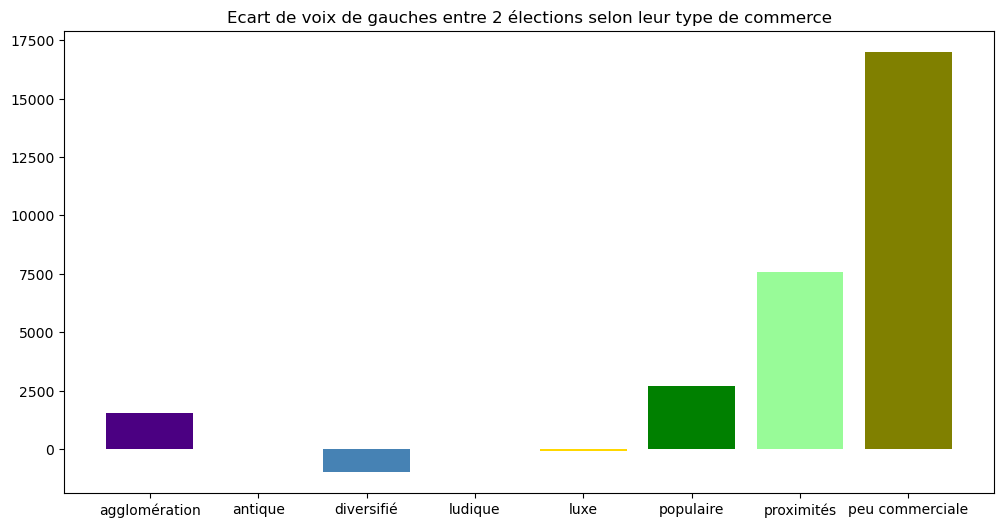

In [86]:

# Diagramme en barre 

plt.figure(figsize=(12,6))


plt.bar(commerce_type,commerce_voixG,color = ['indigo','orange','steelblue','tomato','gold','green','palegreen','olive']) 
plt.title("Ecart de voix de gauches entre 2 élections selon leur type de commerce")

plt.savefig("ecartG_commerce.png")

plt.show()


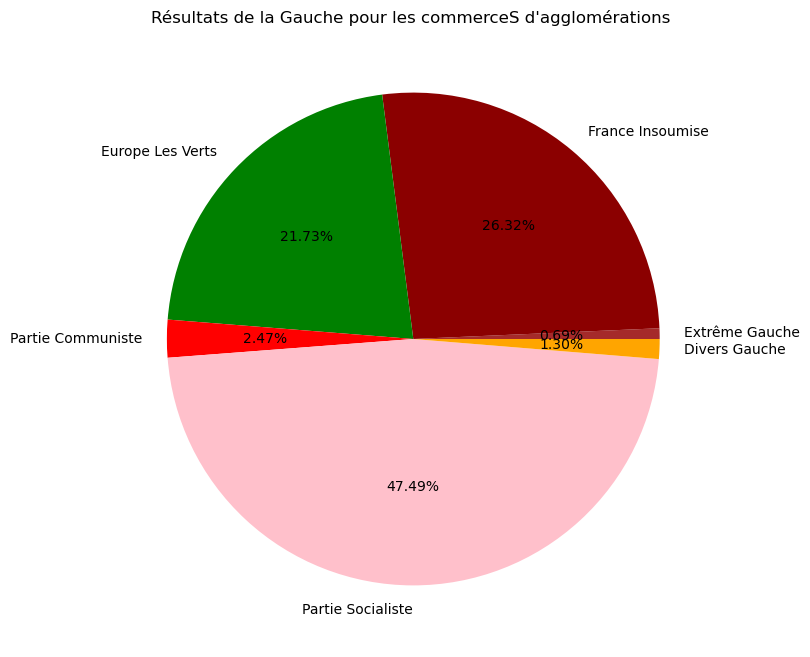

In [88]:
# Agglomération

agglomeration_G = [np.sum(gauche_agglomeration['ExtGauche']),
                   np.sum(gauche_agglomeration['nb_LFI']),
                   np.sum(gauche_agglomeration['nb_EELV']),
                   np.sum(gauche_agglomeration['nb_PCF']),
                   np.sum(gauche_agglomeration['nb_PS']),
                   np.sum(gauche_agglomeration['autresGauche'])]


##Diagramme circulaire

plt.figure(figsize=(12,8))
plt.pie(agglomeration_G,labels = ["Extrême Gauche","France Insoumise","Europe Les Verts","Partie Communiste","Partie Socialiste","Divers Gauche"],
        colors = ['brown','darkred','green','red','pink','orange'],autopct = '%.2f%%')
plt.title("Résultats de la Gauche pour les commerceS d'agglomérations ")
plt.savefig("eur24_G_agglomeration.png")

plt.show()

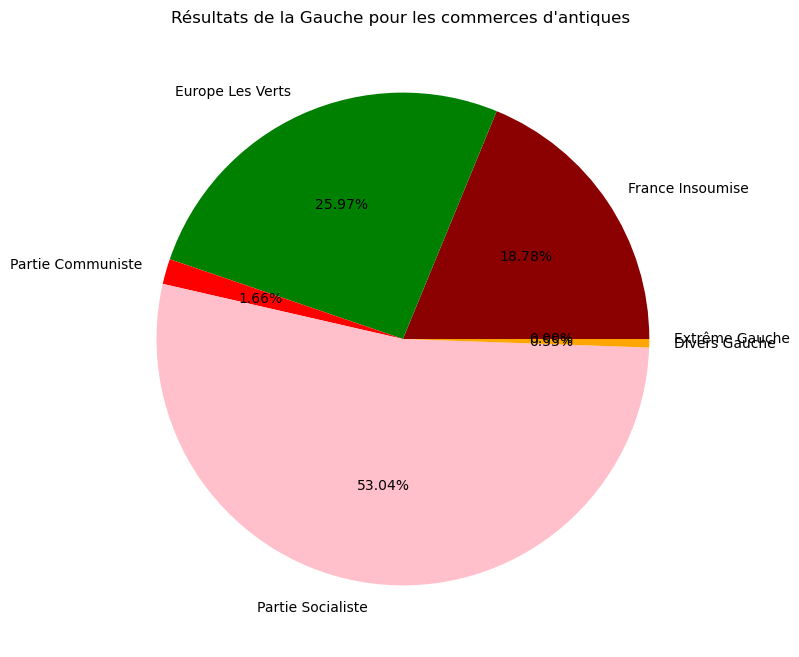

In [89]:
# Commerce antique

antique_G = [np.sum(gauche_antique['ExtGauche']),
             np.sum(gauche_antique['nb_LFI']),
             np.sum(gauche_antique['nb_EELV']),
             np.sum(gauche_antique['nb_PCF']),
             np.sum(gauche_antique['nb_PS']),
             np.sum(gauche_antique['autresGauche'])]


##Diagramme circulaire

plt.figure(figsize=(12,8))
plt.pie(antique_G,labels = ["Extrême Gauche","France Insoumise","Europe Les Verts","Partie Communiste","Partie Socialiste","Divers Gauche"],
        colors = ['brown','darkred','green','red','pink','orange'],autopct = '%.2f%%')
plt.title("Résultats de la Gauche pour les commerces d'antiques ")
plt.savefig("eur24_G_antique.png")

plt.show()

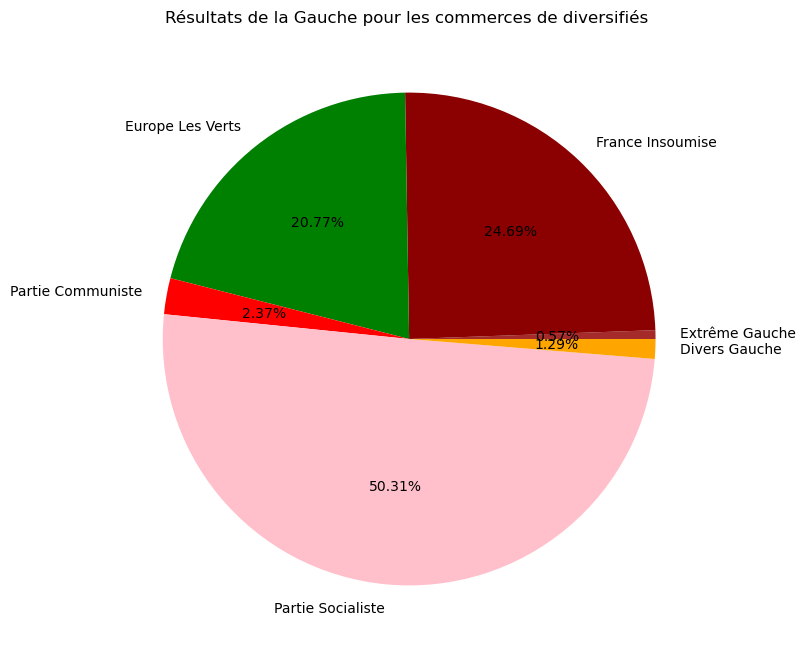

In [90]:
# Commerce de diversité

diversite_G = [np.sum(gauche_diversite['ExtGauche']),
             np.sum(gauche_diversite['nb_LFI']),
             np.sum(gauche_diversite['nb_EELV']),
             np.sum(gauche_diversite['nb_PCF']),
             np.sum(gauche_diversite['nb_PS']),
             np.sum(gauche_diversite['autresGauche'])]


##Diagramme circulaire

plt.figure(figsize=(12,8))
plt.pie(diversite_G,labels = ["Extrême Gauche","France Insoumise","Europe Les Verts","Partie Communiste","Partie Socialiste","Divers Gauche"],
        colors = ['brown','darkred','green','red','pink','orange'],autopct = '%.2f%%')
plt.title("Résultats de la Gauche pour les commerces de diversifiés ")
plt.savefig("eur24_G_diversite.png")

plt.show()

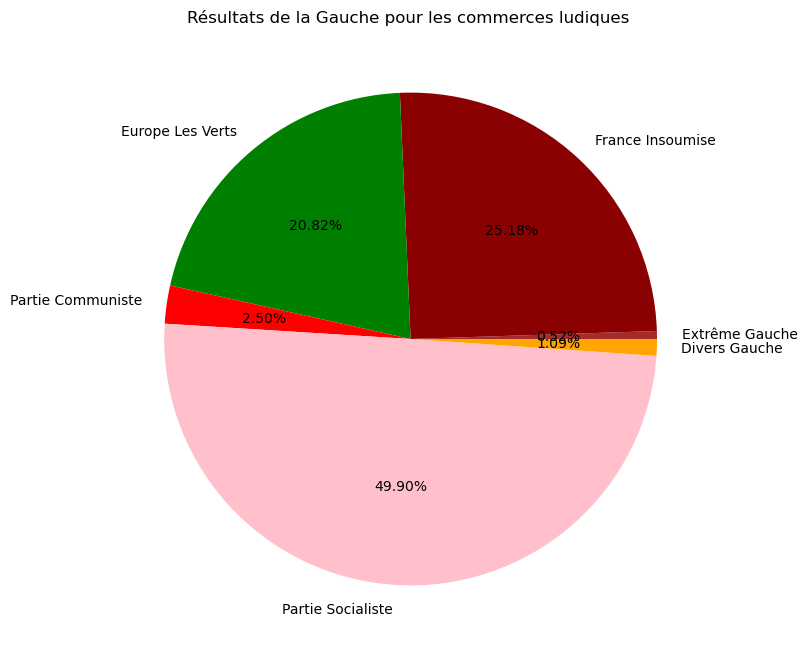

In [91]:
# Commerce de diversité

ludique_G = [np.sum(gauche_ludique['ExtGauche']),
             np.sum(gauche_ludique['nb_LFI']),
             np.sum(gauche_ludique['nb_EELV']),
             np.sum(gauche_ludique['nb_PCF']),
             np.sum(gauche_ludique['nb_PS']),
             np.sum(gauche_ludique['autresGauche'])]


##Diagramme circulaire

plt.figure(figsize=(12,8))
plt.pie(ludique_G,labels = ["Extrême Gauche","France Insoumise","Europe Les Verts","Partie Communiste","Partie Socialiste","Divers Gauche"],
        colors = ['brown','darkred','green','red','pink','orange'],autopct = '%.2f%%')
plt.title("Résultats de la Gauche pour les commerces ludiques ")
plt.savefig("eur24_G_ludique.png")

plt.show()

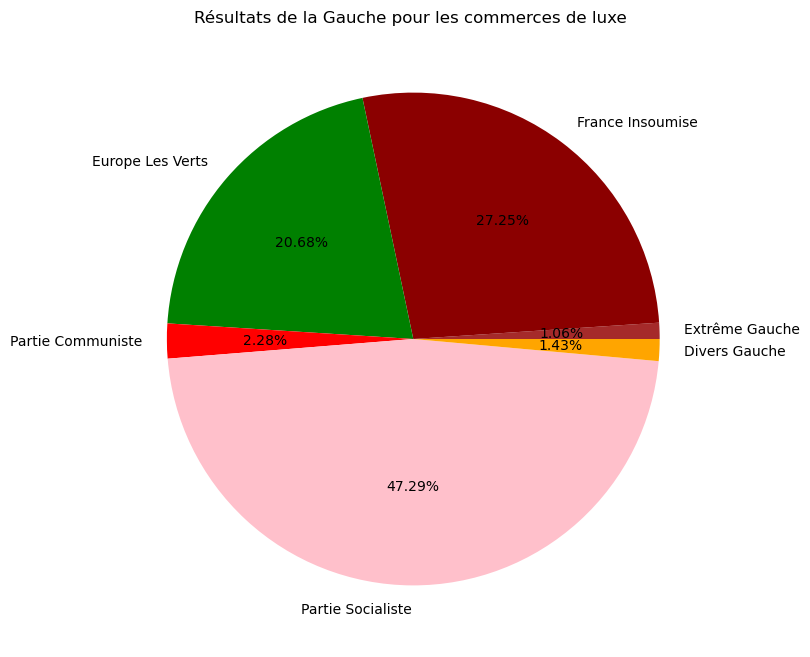

In [92]:
# commerce luxe

luxe_G = [np.sum(gauche_luxe['ExtGauche']),
          np.sum(gauche_luxe['nb_LFI']),
          np.sum(gauche_luxe['nb_EELV']),
          np.sum(gauche_luxe['nb_PCF']),
          np.sum(gauche_luxe['nb_PS']),
          np.sum(gauche_luxe['autresGauche'])]


##Diagramme circulaire

plt.figure(figsize=(12,8))
plt.pie(luxe_G,labels = ["Extrême Gauche","France Insoumise","Europe Les Verts","Partie Communiste","Partie Socialiste","Divers Gauche"],
        colors = ['brown','darkred','green','red','pink','orange'],autopct = '%.2f%%')
plt.title("Résultats de la Gauche pour les commerces de luxe ")
plt.savefig("eur24_G_luxe.png")

plt.show()

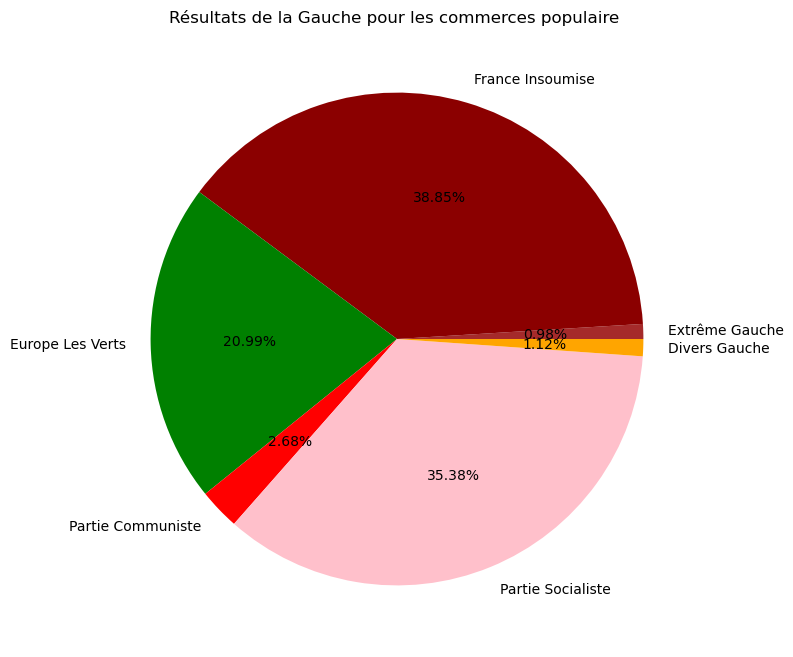

In [93]:
# commerce populaire

populaire_G = [np.sum(gauche_populaire['ExtGauche']),
          np.sum(gauche_populaire['nb_LFI']),
          np.sum(gauche_populaire['nb_EELV']),
          np.sum(gauche_populaire['nb_PCF']),
          np.sum(gauche_populaire['nb_PS']),
          np.sum(gauche_populaire['autresGauche'])]


##Diagramme circulaire

plt.figure(figsize=(12,8))
plt.pie(populaire_G,labels = ["Extrême Gauche","France Insoumise","Europe Les Verts","Partie Communiste","Partie Socialiste","Divers Gauche"],
        colors = ['brown','darkred','green','red','pink','orange'],autopct = '%.2f%%')
plt.title("Résultats de la Gauche pour les commerces populaire ")
plt.savefig("eur24_G_populaire.png")

plt.show()

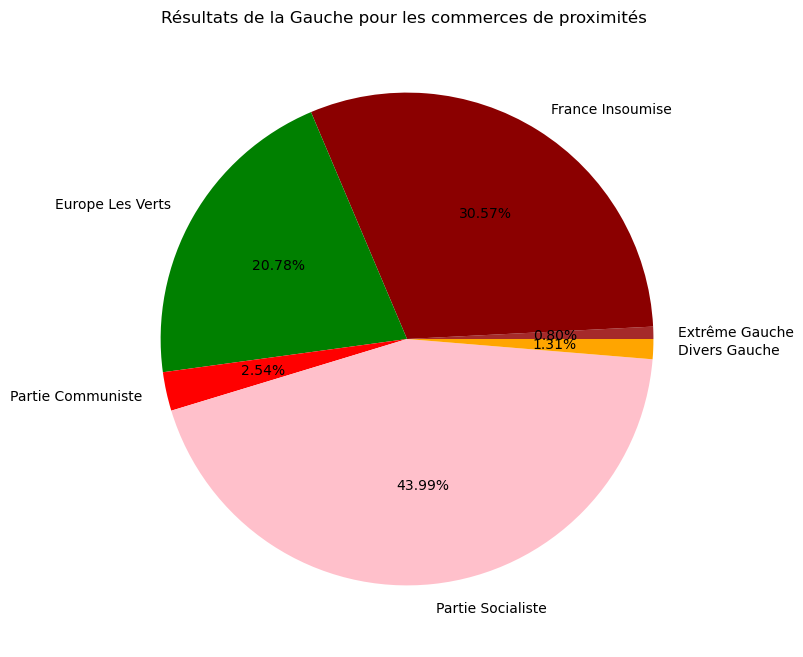

In [94]:
# commerce proximités

proximite_G = [np.sum(gauche_proximite['ExtGauche']),
               np.sum(gauche_proximite['nb_LFI']),
               np.sum(gauche_proximite['nb_EELV']),
               np.sum(gauche_proximite['nb_PCF']),
               np.sum(gauche_proximite['nb_PS']),
               np.sum(gauche_proximite['autresGauche'])]


##Diagramme circulaire

plt.figure(figsize=(12,8))
plt.pie(proximite_G,labels = ["Extrême Gauche","France Insoumise","Europe Les Verts","Partie Communiste","Partie Socialiste","Divers Gauche"],
        colors = ['brown','darkred','green','red','pink','orange'],autopct = '%.2f%%')
plt.title("Résultats de la Gauche pour les commerces de proximités ")
plt.savefig("eur24_G_proximite.png")

plt.show()

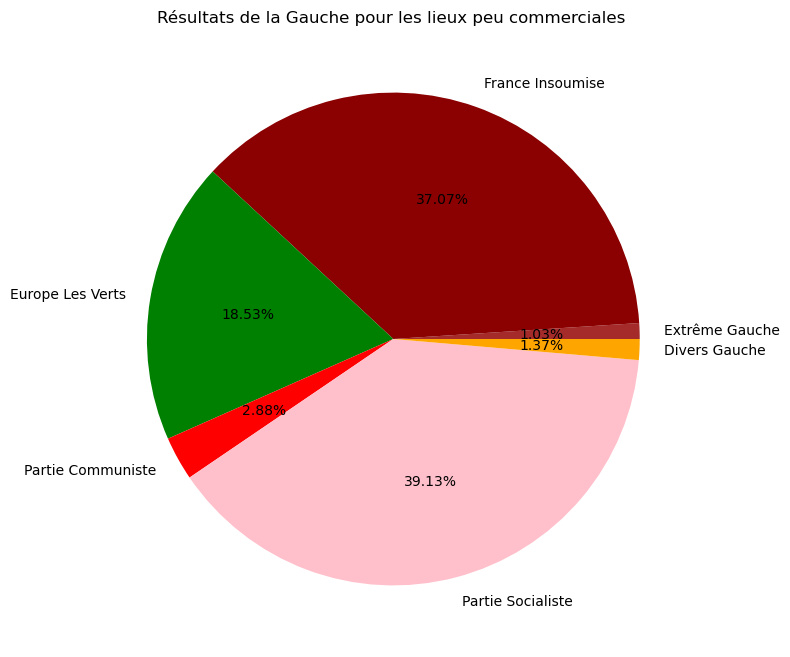

In [95]:
# lieux peu commerciale


peu_com_G = [np.sum(gauche_peu_com['ExtGauche']),
               np.sum(gauche_peu_com['nb_LFI']),
               np.sum(gauche_peu_com['nb_EELV']),
               np.sum(gauche_peu_com['nb_PCF']),
               np.sum(gauche_peu_com['nb_PS']),
               np.sum(gauche_peu_com['autresGauche'])]


##Diagramme circulaire

plt.figure(figsize=(12,8))
plt.pie(peu_com_G,labels = ["Extrême Gauche","France Insoumise","Europe Les Verts","Partie Communiste","Partie Socialiste","Divers Gauche"],
        colors = ['brown','darkred','green','red','pink','orange'],autopct = '%.2f%%')
plt.title("Résultats de la Gauche pour les lieux peu commerciales ")
plt.savefig("eur24_G_peu_com.png")

plt.show()

In [97]:
### Tableau de contingence

tab_G_com = pd.crosstab(gauche_commerce['partie_dominant'],gauche_commerce['type_commerce'],margins=False)
tab_G_com

type_commerce,agglomération,antiquaire,diversifié,ludiques,luxe,peu commerciale,populaire,proximités
partie_dominant,,,,,,,,
La France Insoumise,11,0,1,1,1,117,18,51
Partie Socialiste,174,1,66,9,12,182,11,246


In [98]:
from scipy.stats import chi2_contingency as chi2_contingency

khi2, pval , ddl , contingent_theorique = chi2_contingency(tab_G_com)

In [99]:
khi2

128.33279220906024

In [100]:
pval

1.4014060256875114e-24

In [101]:
ddl

7

In [103]:
pd.DataFrame(contingent_theorique)

,0,1,2,3,4,5,6,7
0,41.065483,0.221976,14.872364,2.219756,2.885683,66.370699,6.437292,65.926748
1,143.934517,0.778024,52.127636,7.780244,10.114317,232.629301,22.562708,231.073252


In [139]:
### Mesure de Cramér

# n = total des effectifs observés
n = tab_G_com.sum().sum()  

# paramètres
chi2 = 128.3
r, c = tab_G_com.shape
v_cramer = np.sqrt(chi2 / (n * (min(r-1, c-1))))

print("V de Cramér =", v_cramer)



V de Cramér = 0.377355715861053


## 2-3 Electorat de droite dans les commerces

In [104]:
# Resultats des européennes

droite =  pd.read_csv('res_droite.csv',sep=';',encoding='ISO-8859-1')

droite = droite.rename(columns = {"ï»¿id_bv":"id_bv"})

droite = droite.set_index('id_bv',drop='True')

#Fusion de données avec les données des logements
droite_commerce = droite.merge(commerce,on='id_bv')

droite_commerce = droite_commerce.set_index('id_bv',drop='True')


droite_commerce.head(10)

,v_D_EUR,p_D_EUR,v_D_LEG,p_D_LEG,ecart_D,nb_LR,nb_RN,nb_Rec,nb_autreDroite,nb_extDroite,partie_dominant,Type_centralités,type_commerce,densité
id_bv,,,,,,,,,,,,,,
01_01,188,"0,2942",166,"0,2147",-22,72,60,42,2,12,Les RÃ©publicains,infra-métropolitaines,luxe,moyenne
01_02,154,"0,2245",164,"0,1832",10,54,54,37,2,7,Les RÃ©publicains,infra-métropolitaines,proximités,forte
01_03,183,"0,2447",195,"0,2252",12,58,71,37,0,17,Rassemblement National,métropolitaine,ludiques,forte
01_04,175,"0,2391",151,"0,1678",-24,51,69,34,1,20,Rassemblement National,métropolitaine,ludiques,forte
01_05,153,"0,2376",138,"0,1687",-15,44,53,41,3,12,Rassemblement National,métropolitaine,diversifié,forte
01_06,230,"0,2934",198,"0,2185",-32,92,85,42,2,9,Les RÃ©publicains,métropolitaine,diversifié,forte
01_07,217,"0,301",171,"0,2122",-46,89,66,43,4,15,Les RÃ©publicains,métropolitaine,diversifié,moyenne
01_08,202,"0,364",185,"0,2753",-17,97,51,44,1,9,Les RÃ©publicains,métropolitaine,antiquaire,forte
01_09,226,"0,3897",188,"0,2831",-38,109,44,64,2,7,Les RÃ©publicains,métropolitaine,diversifié,forte


On split les données selon les type de commerce parisien

In [105]:
#Ancien conforme
droite_agglomeration = droite_commerce[droite_commerce['type_commerce'] == 'agglomération']

#Ancien non conforme
droite_antique = droite_commerce[droite_commerce['type_commerce'] == 'antiquaire']

#Ancien standing
droite_diversite = droite_commerce[droite_commerce['type_commerce'] == 'diversifié']

#Résidence privé récent
droite_ludique = droite_commerce[droite_commerce['type_commerce'] == 'ludiques']

#Logement sociale 
droite_luxe = droite_commerce[droite_commerce['type_commerce'] == 'luxe']

#individuel 
droite_proximite = droite_commerce[droite_commerce['type_commerce'] == 'proximités']

#Logement sociale 
droite_populaire = droite_commerce[droite_commerce['type_commerce'] == 'populaire']

#individuel 
droite_peu_com = droite_commerce[droite_commerce['type_commerce'] == 'peu commerciale']

On calcule les écart des voix de droite en fonction des types de commerce 

In [108]:
## agglomération

agglomeration_voixD = np.sum(droite_agglomeration['ecart_D'])

# antique
antique_voixD = np.sum(droite_antique['ecart_D'])

# diversifié
diversite_voixD = np.sum(droite_diversite['ecart_D'])

## ludiques
ludique_voixD = np.sum(droite_ludique['ecart_D'])

## proximité
proximite_voixD = np.sum(droite_proximite['ecart_D'])

#luxe 
luxe_voixD = np.sum(droite_luxe['ecart_D'])

#populaire
populaire_voixD = np.sum(droite_populaire['ecart_D'])

#peu commercial
peu_com_voixD = np.sum(droite_peu_com['ecart_D'])

ecart_D_commerce = [agglomeration_voixD,antique_voixD,diversite_voixD,ludique_voixD,proximite_voixD,luxe_voixD,populaire_voixD,peu_com_voixD]

ecart_D_commerce

[-4529, -17, -2409, -295, -5118, -420, 90, -3547]

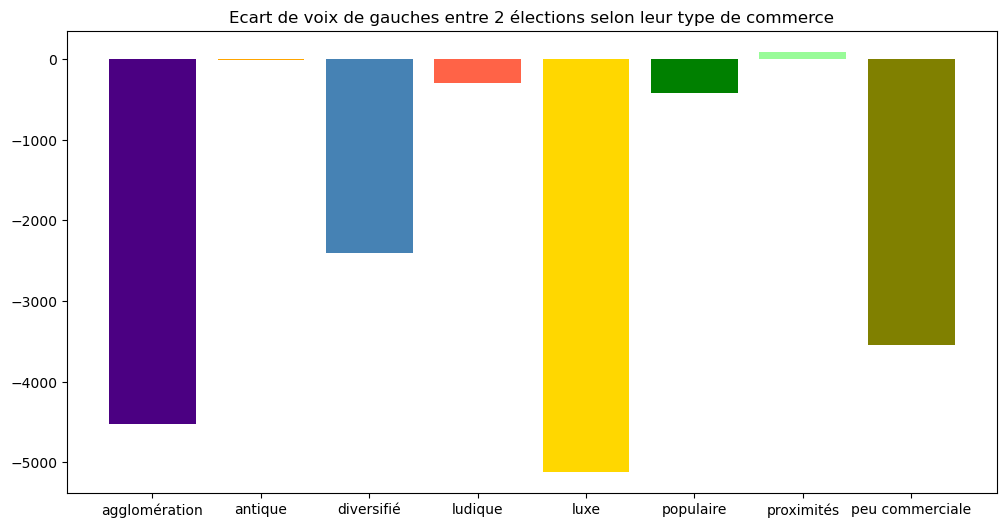

In [110]:
#Représentation graphique des résultats


plt.figure(figsize=(12,6))


plt.bar(commerce_type,ecart_D_commerce,color = ['indigo','orange','steelblue','tomato','gold','green','palegreen','olive']) 
plt.title("Ecart de voix de gauches entre 2 élections selon leur type de commerce")

plt.savefig("ecartD_commerce.png")

plt.show()


#### Analyse par parties politiques 



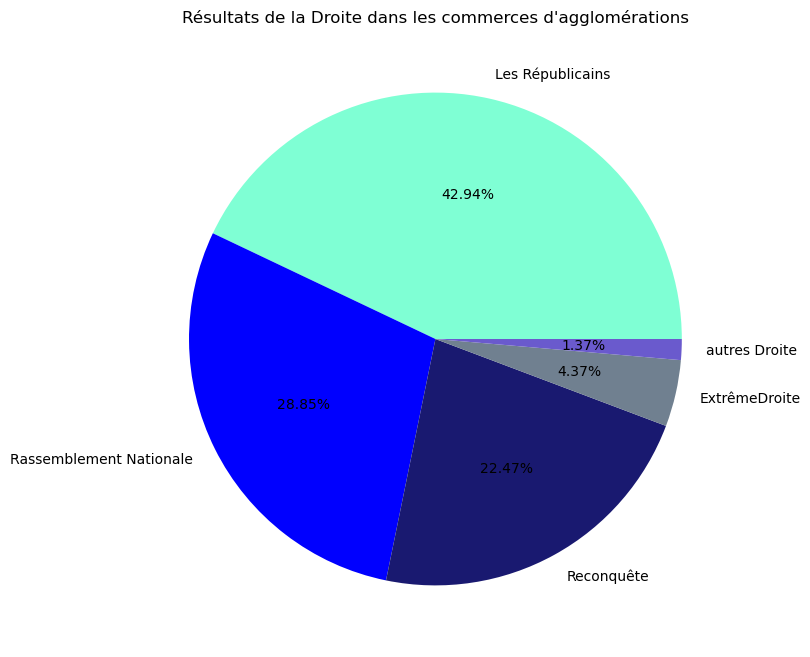

In [112]:
# Commerce d'agglomérations

agglomeration_D = [np.sum(droite_agglomeration['nb_LR']),
                   np.sum(droite_agglomeration['nb_RN']),
                   np.sum(droite_agglomeration['nb_Rec']),
                   np.sum(droite_agglomeration['nb_extDroite']),
                   np.sum(droite_agglomeration['nb_autreDroite'])]


##Diagramme circulaire

plt.figure(figsize=(10,8))
plt.pie(agglomeration_D,labels = ["Les Républicains","Rassemblement Nationale","Reconquête","ExtrêmeDroite","autres Droite"],
        colors = ['aquamarine','blue','midnightblue','slategrey','slateblue'],autopct = '%.2f%%')
plt.title("Résultats de la Droite dans les commerces d'agglomérations")
plt.savefig("eur24_D_agglomération.png")



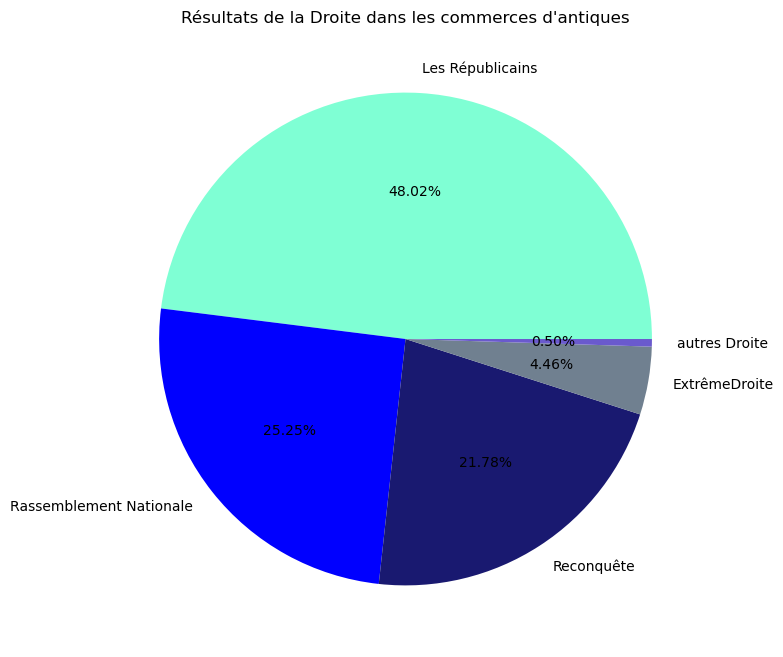

In [113]:
# Commerce d'antiquités

antique_D = [np.sum(droite_antique['nb_LR']),
             np.sum(droite_antique['nb_RN']),
             np.sum(droite_antique['nb_Rec']),
             np.sum(droite_antique['nb_extDroite']),
             np.sum(droite_antique['nb_autreDroite'])]


##Diagramme circulaire

plt.figure(figsize=(10,8))
plt.pie(antique_D,labels = ["Les Républicains","Rassemblement Nationale","Reconquête","ExtrêmeDroite","autres Droite"],
        colors = ['aquamarine','blue','midnightblue','slategrey','slateblue'],autopct = '%.2f%%')
plt.title("Résultats de la Droite dans les commerces d'antiques")
plt.savefig("eur24_D_antiques.png")



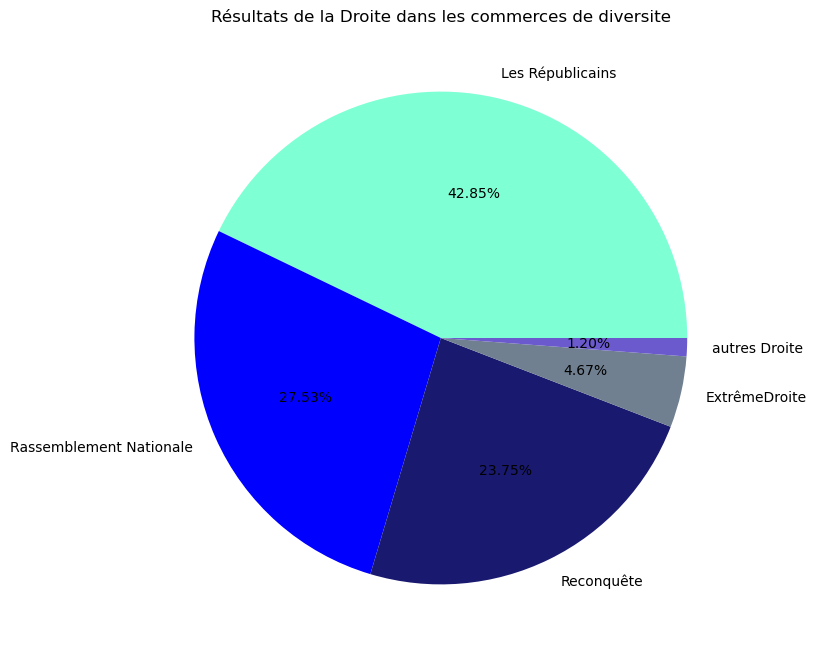

In [114]:
# Commerce de diversité

diversite_D = [np.sum(droite_diversite['nb_LR']),
               np.sum(droite_diversite['nb_RN']),
               np.sum(droite_diversite['nb_Rec']),
               np.sum(droite_diversite['nb_extDroite']),
               np.sum(droite_diversite['nb_autreDroite'])]


##Diagramme circulaire

plt.figure(figsize=(10,8))
plt.pie(diversite_D,labels = ["Les Républicains","Rassemblement Nationale","Reconquête","ExtrêmeDroite","autres Droite"],
        colors = ['aquamarine','blue','midnightblue','slategrey','slateblue'],autopct = '%.2f%%')
plt.title("Résultats de la Droite dans les commerces de diversite")
plt.savefig("eur24_D_diversites.png")


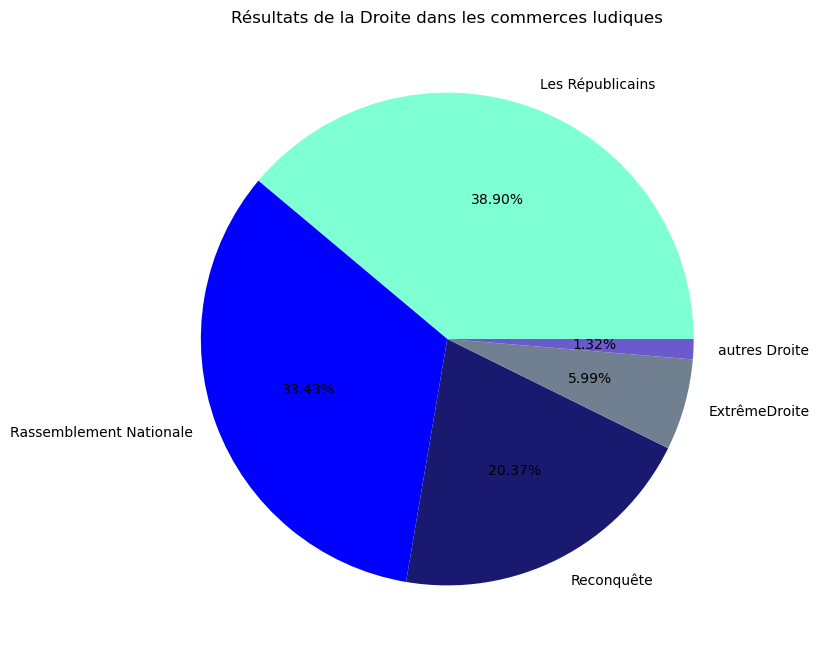

In [116]:
# Commerce lidiques

ludique_D = [np.sum(droite_ludique['nb_LR']),
             np.sum(droite_ludique['nb_RN']),
             np.sum(droite_ludique['nb_Rec']),
             np.sum(droite_ludique['nb_extDroite']),
             np.sum(droite_ludique['nb_autreDroite'])]


##Diagramme circulaire

plt.figure(figsize=(10,8))
plt.pie(ludique_D,labels = ["Les Républicains","Rassemblement Nationale","Reconquête","ExtrêmeDroite","autres Droite"],
        colors = ['aquamarine','blue','midnightblue','slategrey','slateblue'],autopct = '%.2f%%')
plt.title("Résultats de la Droite dans les commerces ludiques")
plt.savefig("eur24_D_ludiques.png")


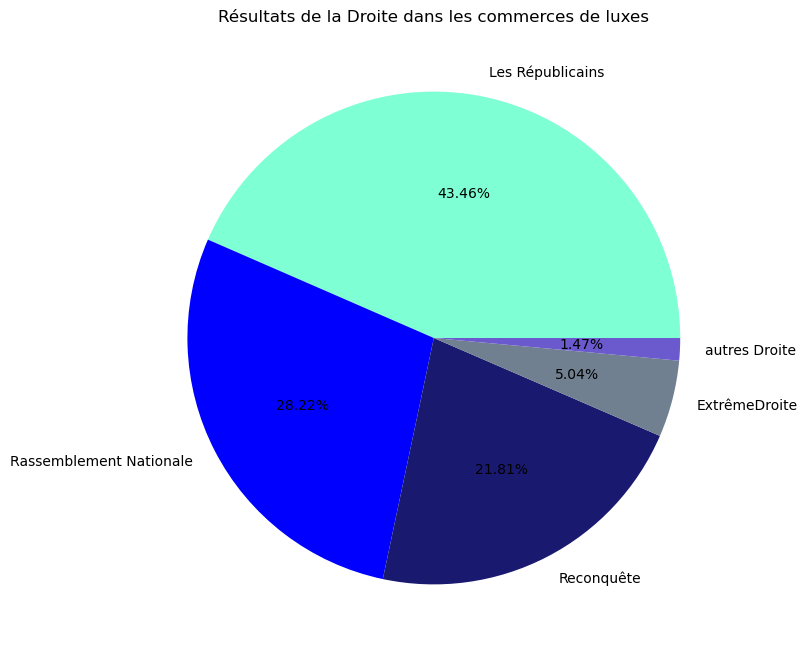

In [117]:
# Commerce d'antiquités

luxe_D = [np.sum(droite_luxe['nb_LR']),
          np.sum(droite_luxe['nb_RN']),
          np.sum(droite_luxe['nb_Rec']),
          np.sum(droite_luxe['nb_extDroite']), 
          np.sum(droite_luxe['nb_autreDroite'])]


##Diagramme circulaire

plt.figure(figsize=(10,8))
plt.pie(luxe_D,labels = ["Les Républicains","Rassemblement Nationale","Reconquête","ExtrêmeDroite","autres Droite"],
        colors = ['aquamarine','blue','midnightblue','slategrey','slateblue'],autopct = '%.2f%%')
plt.title("Résultats de la Droite dans les commerces de luxes")
plt.savefig("eur24_D_luxe.png")


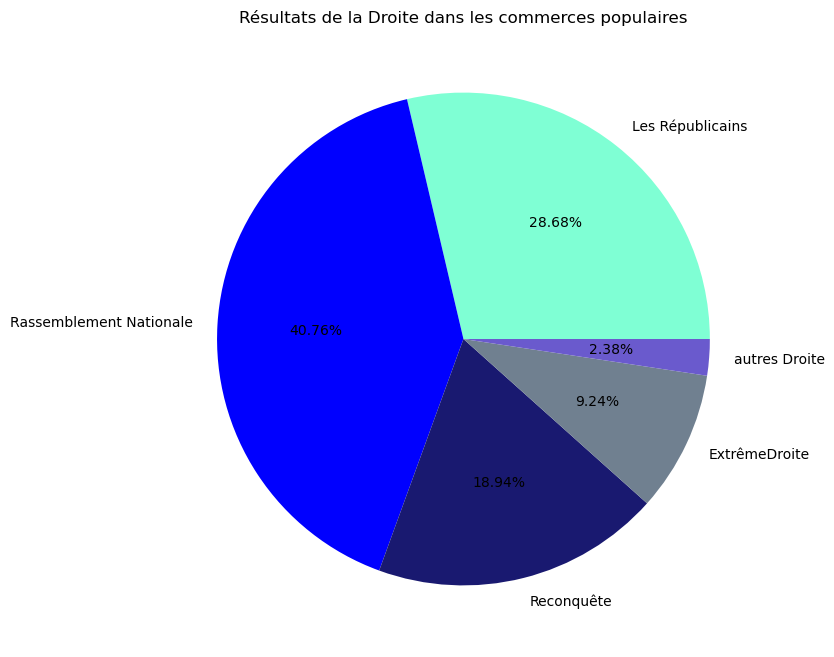

In [118]:
# Commerce d'antiquités

populaire_D = [np.sum(droite_populaire['nb_LR']),
               np.sum(droite_populaire['nb_RN']),
               np.sum(droite_populaire['nb_Rec']),
               np.sum(droite_populaire['nb_extDroite']), 
               np.sum(droite_populaire['nb_autreDroite'])]


##Diagramme circulaire

plt.figure(figsize=(10,8))
plt.pie(populaire_D,labels = ["Les Républicains","Rassemblement Nationale","Reconquête","ExtrêmeDroite","autres Droite"],
        colors = ['aquamarine','blue','midnightblue','slategrey','slateblue'],autopct = '%.2f%%')
plt.title("Résultats de la Droite dans les commerces populaires")
plt.savefig("eur24_D_populaire.png")


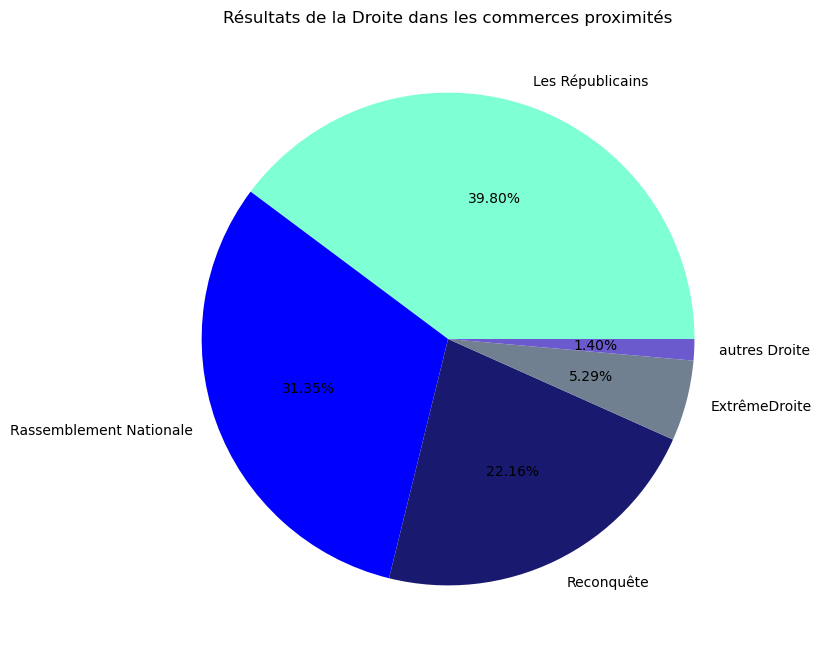

In [119]:
# Commerce de proximités

proximite_D = [np.sum(droite_proximite['nb_LR']),
               np.sum(droite_proximite['nb_RN']),
               np.sum(droite_proximite['nb_Rec']),
               np.sum(droite_proximite['nb_extDroite']), 
               np.sum(droite_proximite['nb_autreDroite'])]


##Diagramme circulaire

plt.figure(figsize=(10,8))
plt.pie(proximite_D,labels = ["Les Républicains","Rassemblement Nationale","Reconquête","ExtrêmeDroite","autres Droite"],
        colors = ['aquamarine','blue','midnightblue','slategrey','slateblue'],autopct = '%.2f%%')
plt.title("Résultats de la Droite dans les commerces proximités")
plt.savefig("eur24_D_proximite.png")


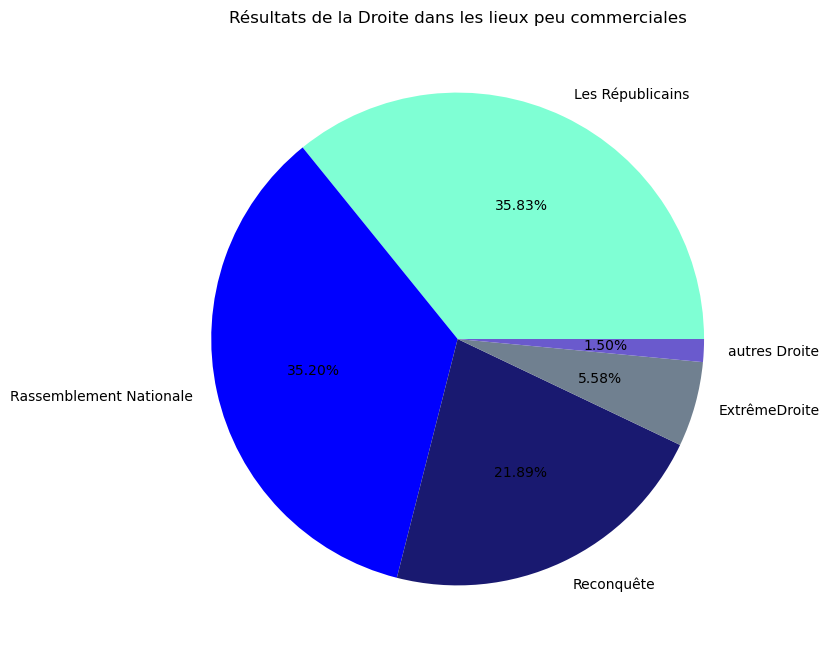

In [123]:
# Commerce d'antiquités

peu_commerciale_D = [np.sum(droite_peu_com['nb_LR']),
                     np.sum(droite_peu_com['nb_RN']),
                     np.sum(droite_peu_com['nb_Rec']),
                     np.sum(droite_peu_com['nb_extDroite']), 
                     np.sum(droite_peu_com['nb_autreDroite'])]


##Diagramme circulaire

plt.figure(figsize=(10,8))
plt.pie(peu_commerciale_D,labels = ["Les Républicains","Rassemblement Nationale","Reconquête","ExtrêmeDroite","autres Droite"],
        colors = ['aquamarine','blue','midnightblue','slategrey','slateblue'],autopct = '%.2f%%')
plt.title("Résultats de la Droite dans les lieux peu commerciales")
plt.savefig("eur24_D_peu_commerciale.png")


In [124]:
### Tableau de contingence

tab_D_com = pd.crosstab(droite_commerce['partie_dominant'],droite_commerce['type_commerce'],margins=False)
tab_D_com

type_commerce,agglomération,antiquaire,diversifié,ludiques,luxe,peu commerciale,populaire,proximités
partie_dominant,,,,,,,,
Les RÃ©publicains,129,1,54,5,10,107,6,170
Rassemblement National,56,0,13,5,3,191,23,125
ReconquÃªte,0,0,0,0,0,1,0,2


In [125]:
from scipy.stats import chi2_contingency as chi2_contingency

khi2, pval , ddl , contingent_theorique = chi2_contingency(tab_D_com)

In [126]:
khi2

97.06696993060473

In [127]:
pval

1.7259778239703183e-14

In [128]:
ddl

14

In [138]:
### Mesure de Cramér

# n = total des effectifs observés
n = tab_D_com.sum().sum()  

# paramètres
chi2 = 97
r, c = tab_D_com.shape
v_cramer = np.sqrt(chi2 / (n * (min(r-1, c-1))))

print("V de Cramér =", v_cramer)



V de Cramér = 0.23201094543433043


# 3 - Analyse qualitatives 

On va analyser les deux type de commerce et d'habitation ensemble avec l'aide d'un tableau de contingence

In [129]:
#Fusion des table commerce et logement

log_com = logement.merge(commerce,on='id_bv')
log_com

,id_bv,habitat_principal,statut_logSocial,pour_logSocial,pourct_T1/T2,prix_immo_m2,Type_centralités,type_commerce,densité
0,01_01,ancien_standing,déficit,0.01,0.20,12.7,infra-métropolitaines,luxe,moyenne
1,01_02,ancien_non_conforme,déficit,0.05,0.65,13.0,infra-métropolitaines,proximités,forte
2,01_03,ancien_conforme,déficit,0.05,0.80,10.0,métropolitaine,ludiques,forte
3,01_04,ancien_conforme,déficit,0.05,0.80,10.3,métropolitaine,ludiques,forte
4,01_05,ancien_conforme,conforme,0.30,0.80,9.5,métropolitaine,diversifié,forte
...,...,...,...,...,...,...,...,...,...
896,20_72,ancien_non_conforme,conforme,0.55,0.55,5.1,infra-métropolitaines,proximités,faible
897,20_73,ancien_non_conforme,déficit,0.15,0.65,5.6,infra-métropolitaines,proximités,moyenne
898,20_74,ancien_non_conforme,conforme,0.30,0.70,5.0,infra-métropolitaines,agglomération,moyenne
899,20_75,logement_social,déficit,0.25,0.67,4.2,infra-métropolitaines,proximités,faible


### 4-1 Tableau de contingence

In [130]:
### Tableau de contingence

tab = pd.crosstab(log_com['type_commerce'],log_com['habitat_principal'],margins=False)
tab

habitat_principal,ancien_conforme,ancien_non_conforme,ancien_standing,individuel,logement_social,privé récent
type_commerce,,,,,,
agglomération,82,36,27,0,15,25
antiquaire,1,0,0,0,0,0
diversifié,34,16,13,0,2,2
ludiques,6,2,0,0,0,2
luxe,5,0,6,0,0,2
peu commerciale,42,34,24,6,96,97
populaire,4,20,0,0,3,2
proximités,98,73,27,1,35,63


### 4-2 Test de Khi-2

In [132]:
from scipy.stats import chi2_contingency as chi2_contingency

khi2, pval , ddl , contingent_theorique = chi2_contingency(tab)

In [133]:
khi2

249.410263343256

In [134]:
pval

3.5622721850202844e-34

In [135]:
ddl

35

In [136]:
pd.DataFrame(contingent_theorique)

,0,1,2,3,4,5
0,55.849057,37.164262,19.916759,1.437292,31.004440,39.628191
1,0.301887,0.200888,0.107658,0.007769,0.167592,0.214206
2,20.226415,13.459489,7.213097,0.520533,11.228635,14.351831
3,3.018868,2.008879,1.076582,0.077691,1.675916,2.142064
4,3.924528,2.611543,1.399556,0.100999,2.178690,2.784684
5,90.264151,60.065483,32.189789,2.322974,50.109878,64.047725
6,8.754717,5.825749,3.122087,0.225305,4.860155,6.211987
7,89.660377,59.663707,31.974473,2.307436,49.774695,63.619312


#### Mesure de Cramér 

On peut utiliser l’indice de V de Cramér pour mesurer la force de l’association entre deux variables catégorielles.

In [137]:
# n = total des effectifs observés
n = tab.sum().sum()  

# paramètres
chi2 = 249.418263343256
r, c = tab.shape
v_cramer = np.sqrt(chi2 / (n * (min(r-1, c-1))))

print("V de Cramér =", v_cramer)

V de Cramér = 0.23529718302207878


le lien est plutôt faible, donc les variables ne sont pas totalement indépendantes, mais l’association n’est pas très forte non plus.

Il existe bien une association significative entre tes deux variables (confirmée par le test du khi-2).

Mais la force de ce lien est faible à modérée.